In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

# describe 결과 불러오기
desc = pd.read_csv("../data/describe_summary.csv", index_col=0)

# 2. 원본 데이터 불러오기
df = pd.read_csv("../data/train.csv")

In [54]:
# 3. IQR 기반 이상치 기준 계산
Q1 = desc.loc["25%"]
Q3 = desc.loc["75%"]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [55]:
# 이상치 마스킹 예시 (컬럼별로)
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.select_dtypes(include="number").columns:
    if col in lower_bound.index:
        lb = lower_bound[col]
        ub = upper_bound[col]
        outlier_mask[col] = (df[col] < lb) | (df[col] > ub)

# 5. 이상치 기준 + 마스크를 outlier_bounds에 통합
outlier_bounds = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "LowerBound": lower_bound,
    "UpperBound": upper_bound,
    "OutlierCount": outlier_mask.sum()
})

print(outlier_bounds)


                                 Q1           Q3       IQR  LowerBound  \
ID                       38104.7500  113748.7500  75644.00 -75361.2500   
var3                         2.0000       2.0000      0.00      2.0000   
var15                       23.0000      40.0000     17.00     -2.5000   
imp_ent_var16_ult1           0.0000       0.0000      0.00      0.0000   
imp_op_var39_comer_ult1      0.0000       0.0000      0.00      0.0000   
...                             ...          ...       ...         ...   
saldo_medio_var44_hace3      0.0000       0.0000      0.00      0.0000   
saldo_medio_var44_ult1       0.0000       0.0000      0.00      0.0000   
saldo_medio_var44_ult3       0.0000       0.0000      0.00      0.0000   
var38                    67870.6125  118756.2525  50885.64  -8457.8475   
TARGET                       0.0000       0.0000      0.00      0.0000   

                          UpperBound  OutlierCount  
ID                       227214.7500             0  
var3 

In [39]:
outlier_bounds.to_csv('../data/outlier_bounds.csv')

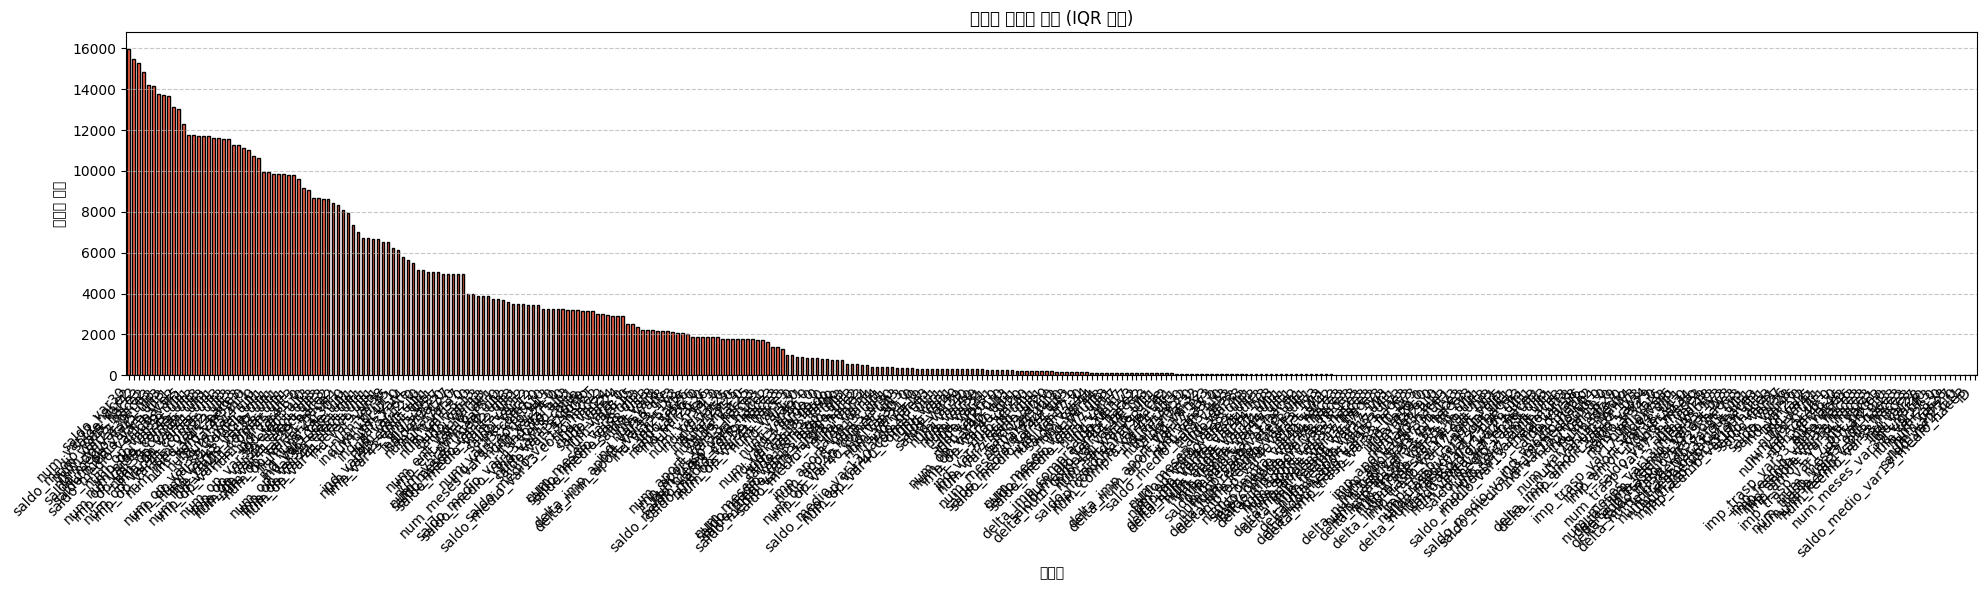

In [56]:
# 시각화
outlier_series = outlier_bounds['OutlierCount'].sort_values(ascending=False)

plt.figure(figsize=(20, 6))
outlier_series.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("컬럼별 이상치 개수 (IQR 기준)")
plt.ylabel("이상치 개수")
plt.xlabel("컬럼명")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [57]:
outlier_series[outlier_series > 100]
# 0 보다 큰  331개
# 10 보다 큰 260개
# 50 보다 큰 221개
# 100 보다 큰 204개

saldo_var30                   15983
num_var22_hace2               15479
saldo_var42                   15281
saldo_medio_var5_hace3        14864
num_var45_hace2               14196
                              ...  
num_var17                       110
ind_var17                       110
saldo_var17                     110
delta_imp_compra_var44_1y3      102
num_op_var40_hace2              102
Name: OutlierCount, Length: 204, dtype: int64

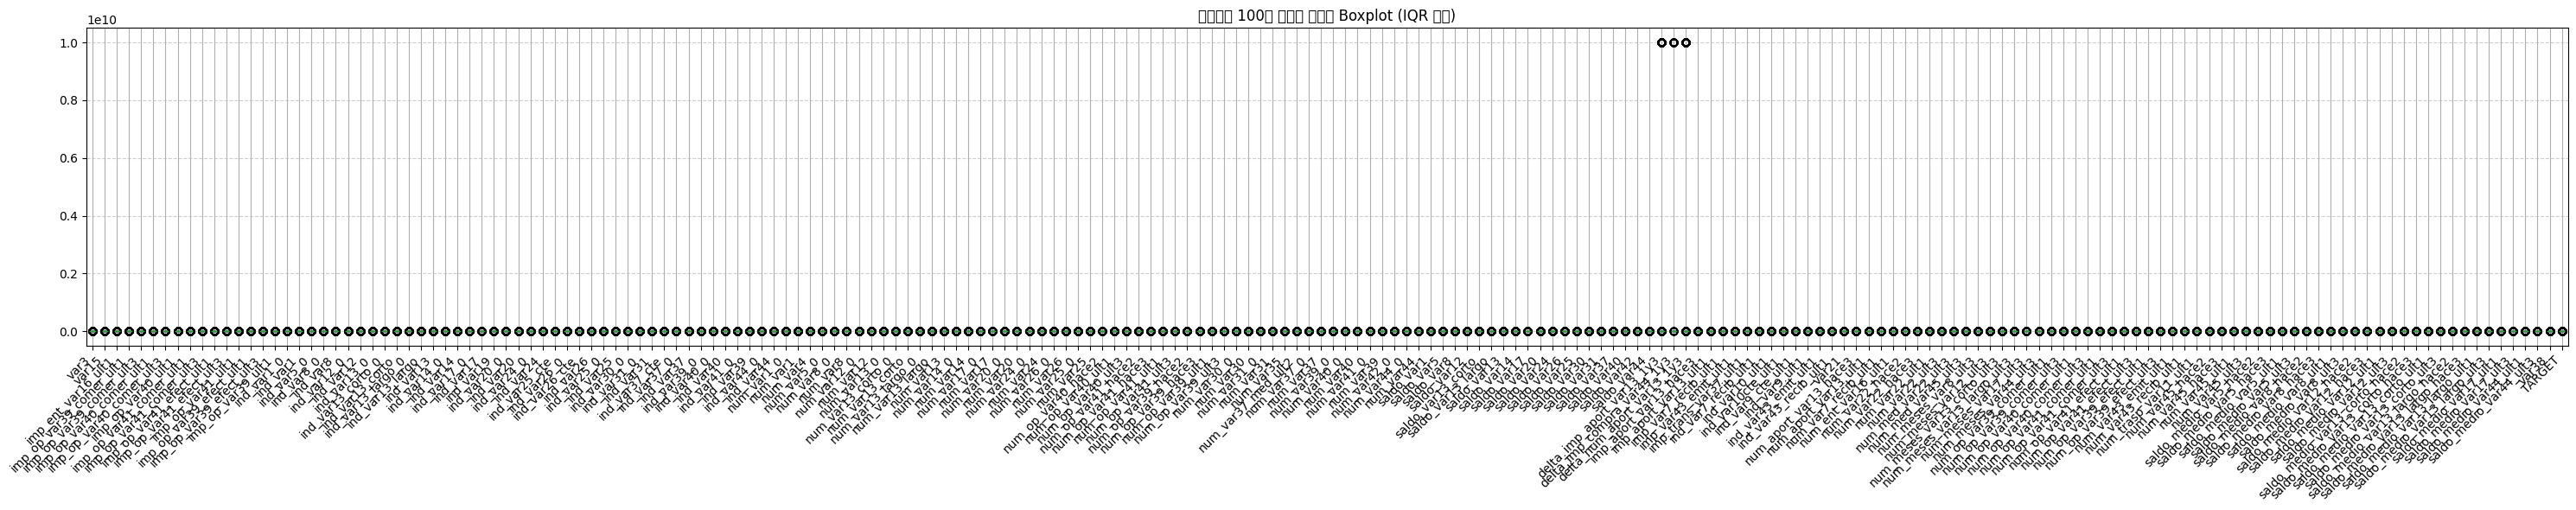

In [58]:
# 5. 이상치가 n개 이상인 컬럼만 필터링
ncnt = 100
selected_cols = outlier_bounds[outlier_bounds["OutlierCount"] > ncnt].index.tolist()

# 6. Boxplot 시각화
plt.figure(figsize=(30, 6))
df[selected_cols].boxplot()
plt.title(f"이상치가 {ncnt}개 이상인 컬럼의 Boxplot (IQR 기준)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


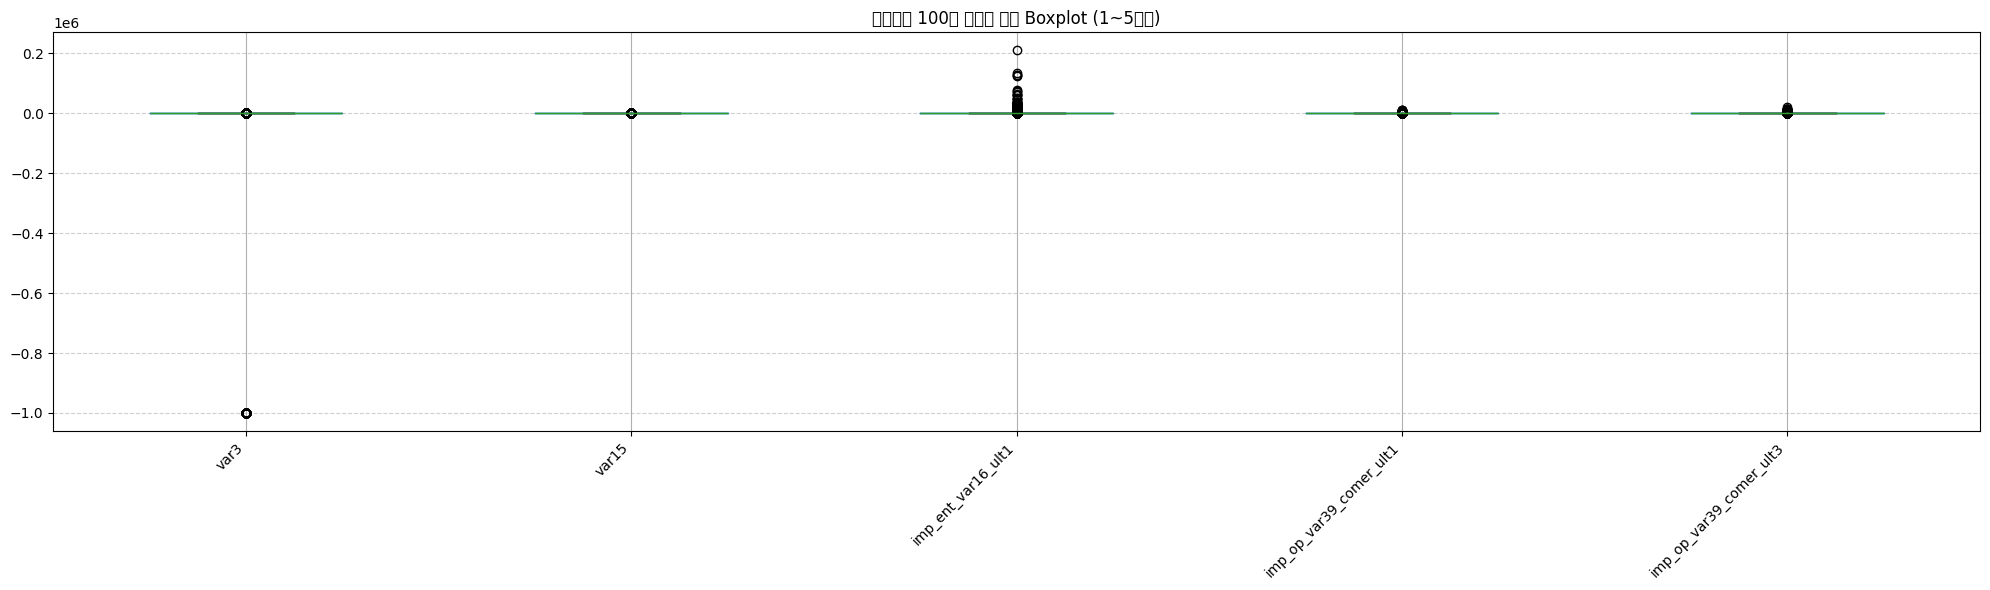

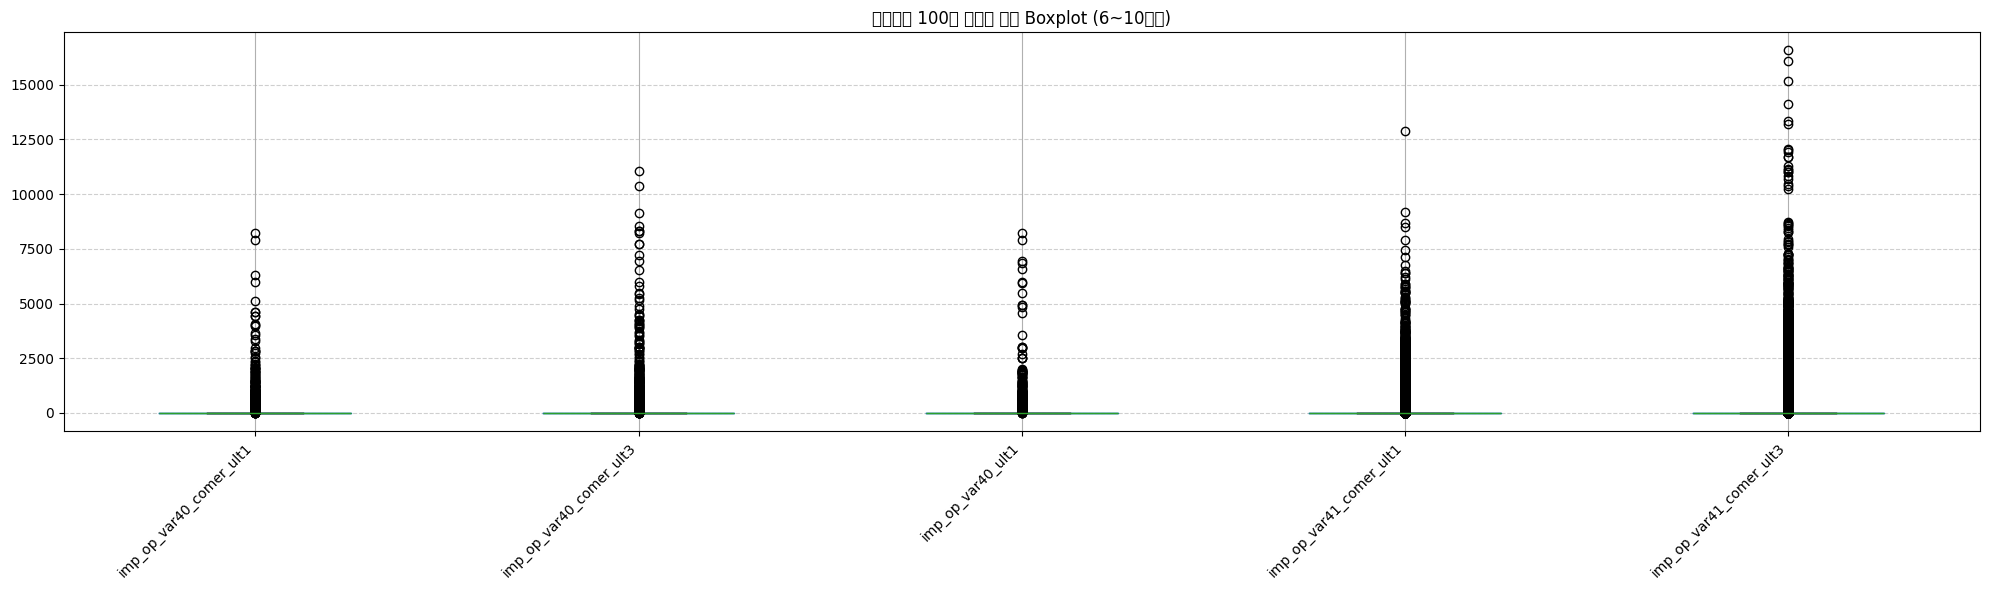

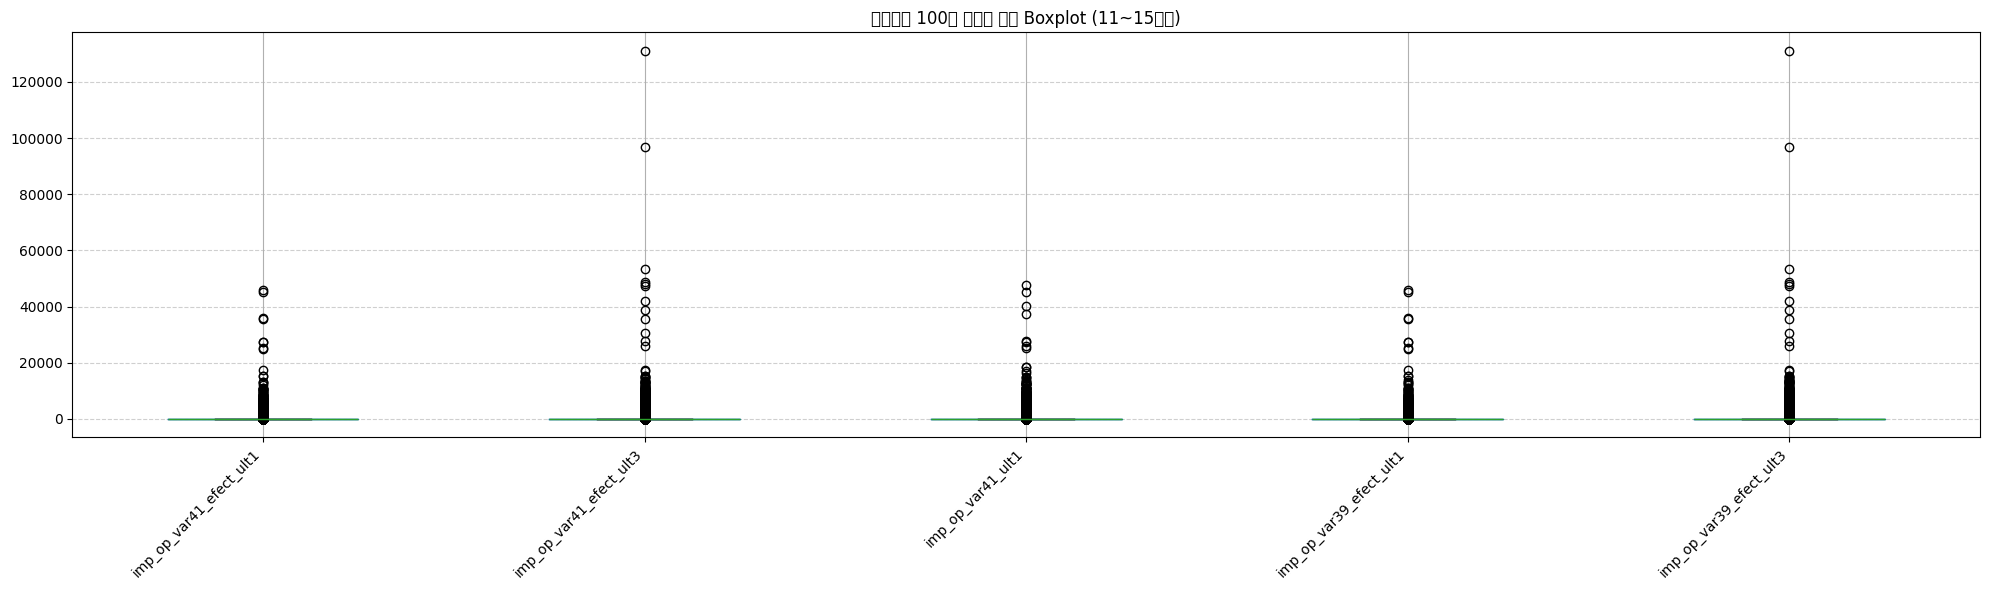

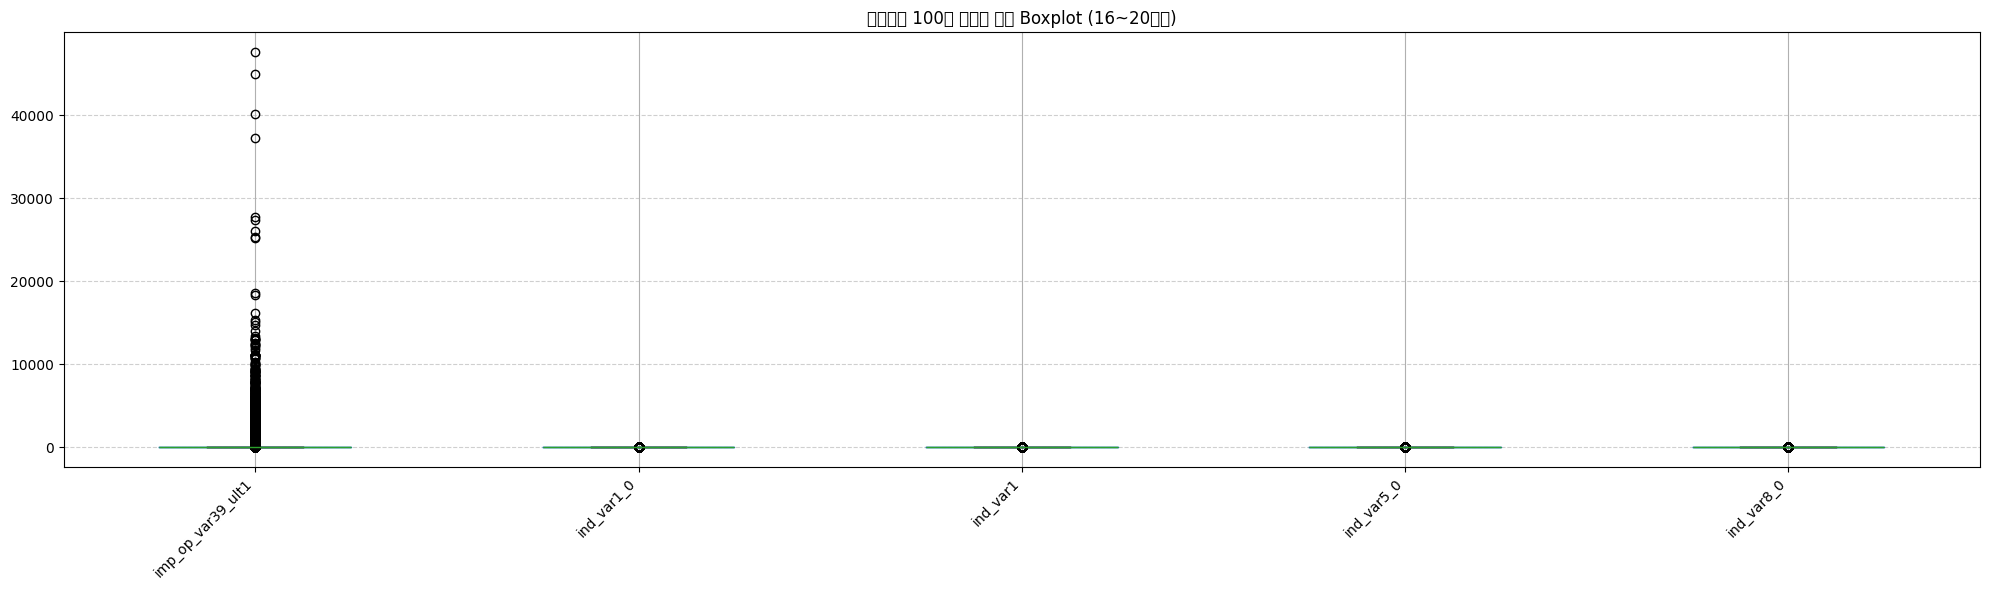

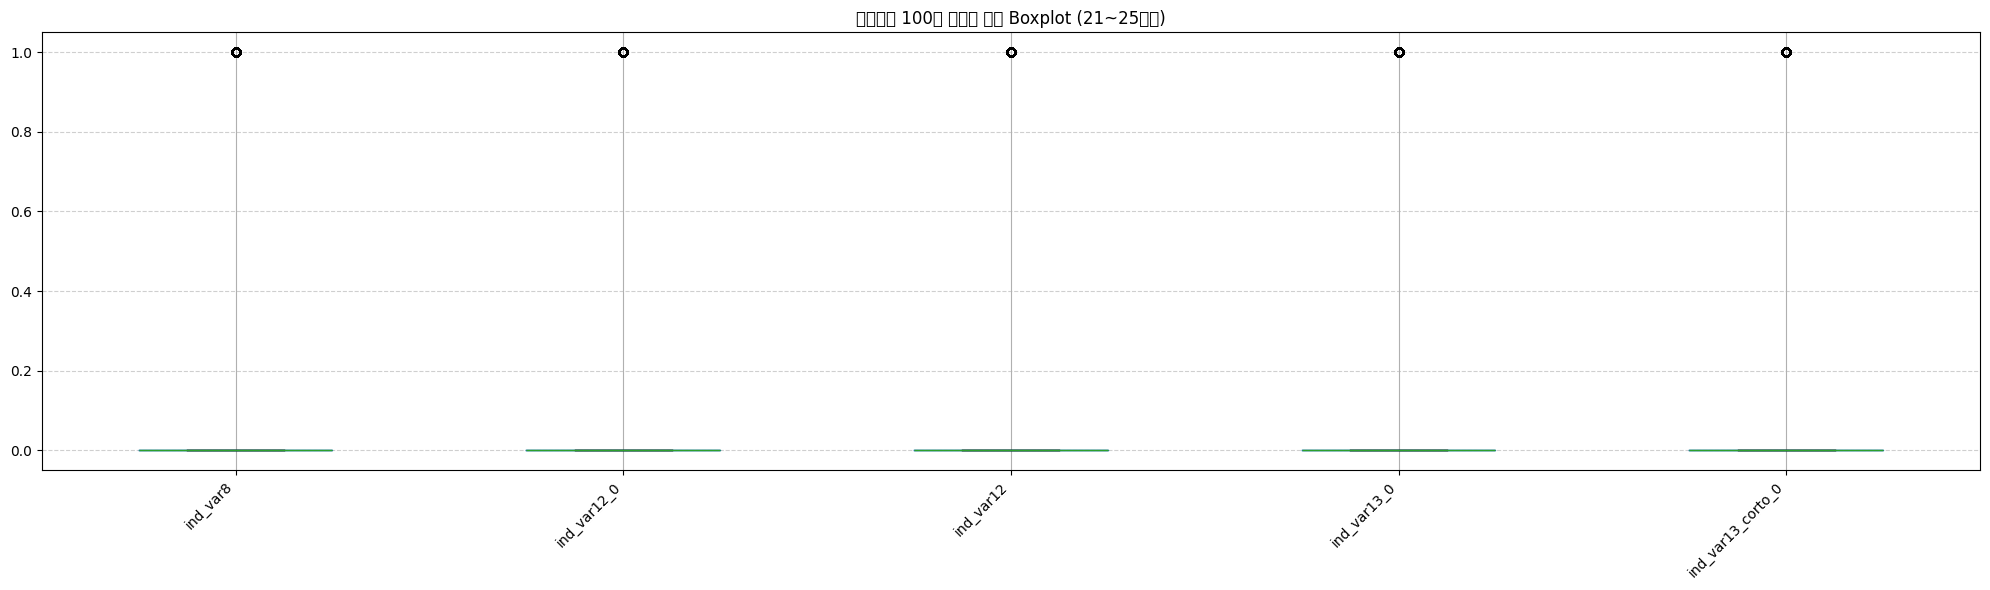

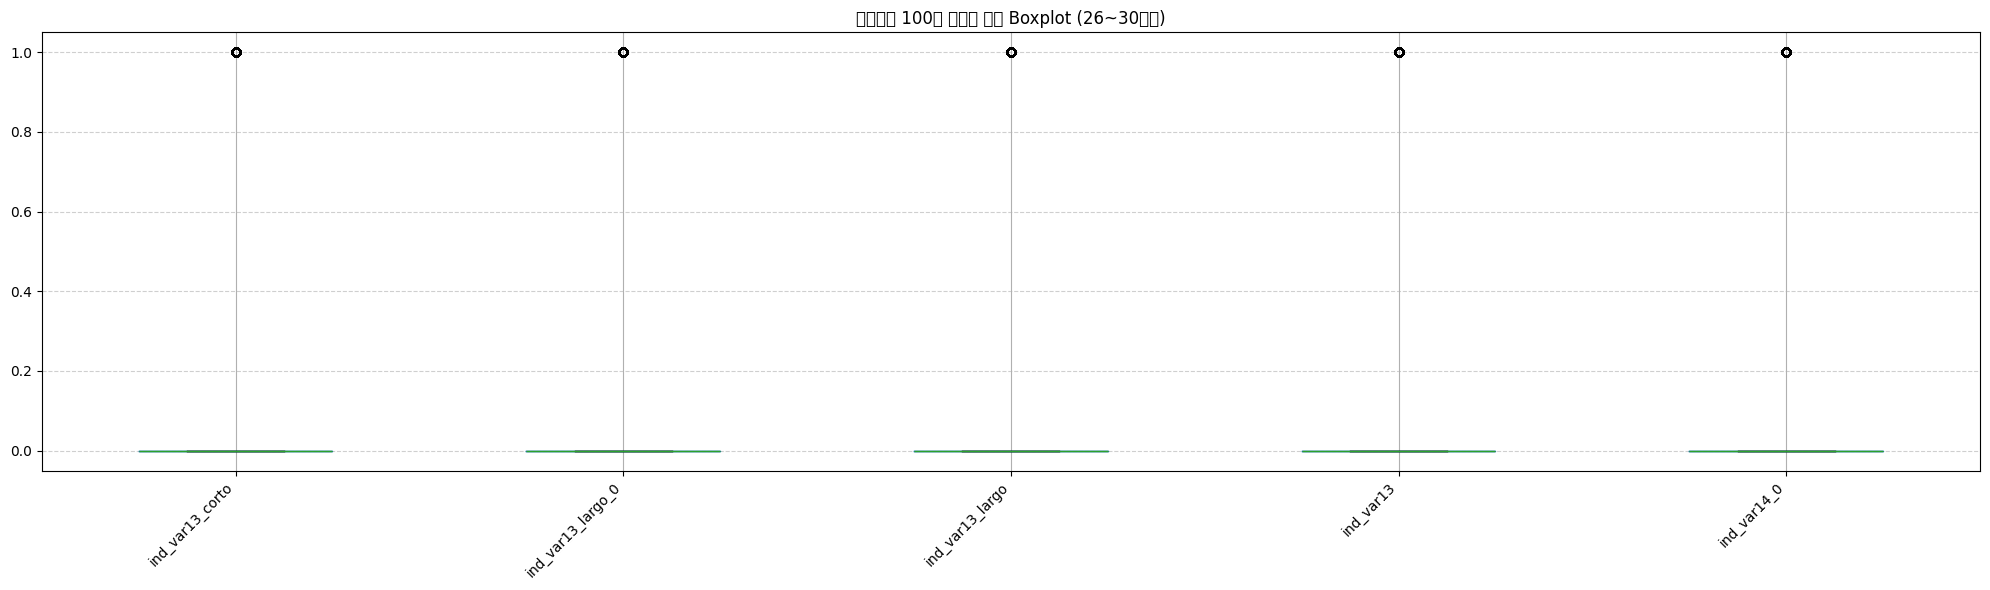

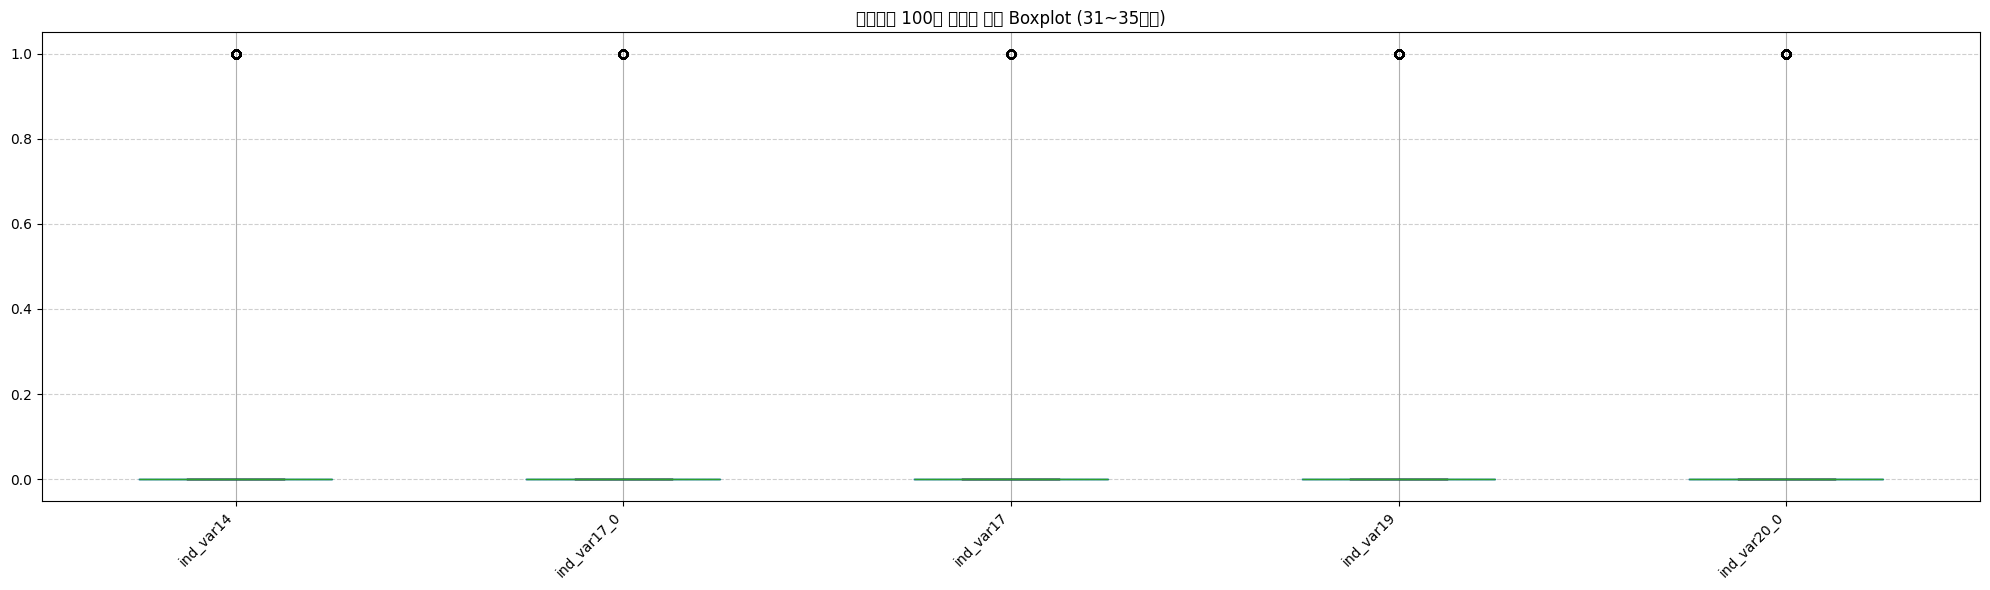

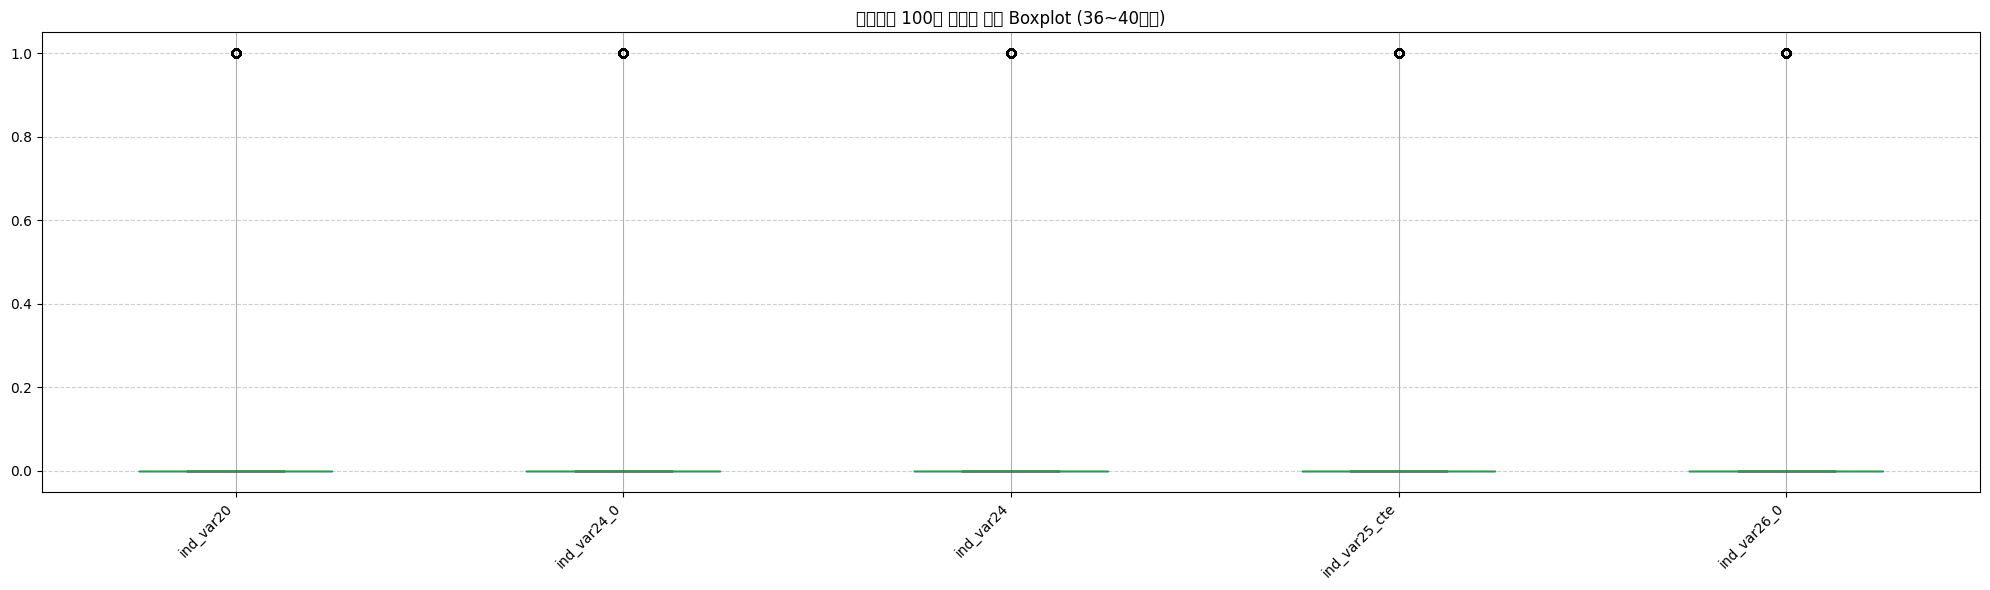

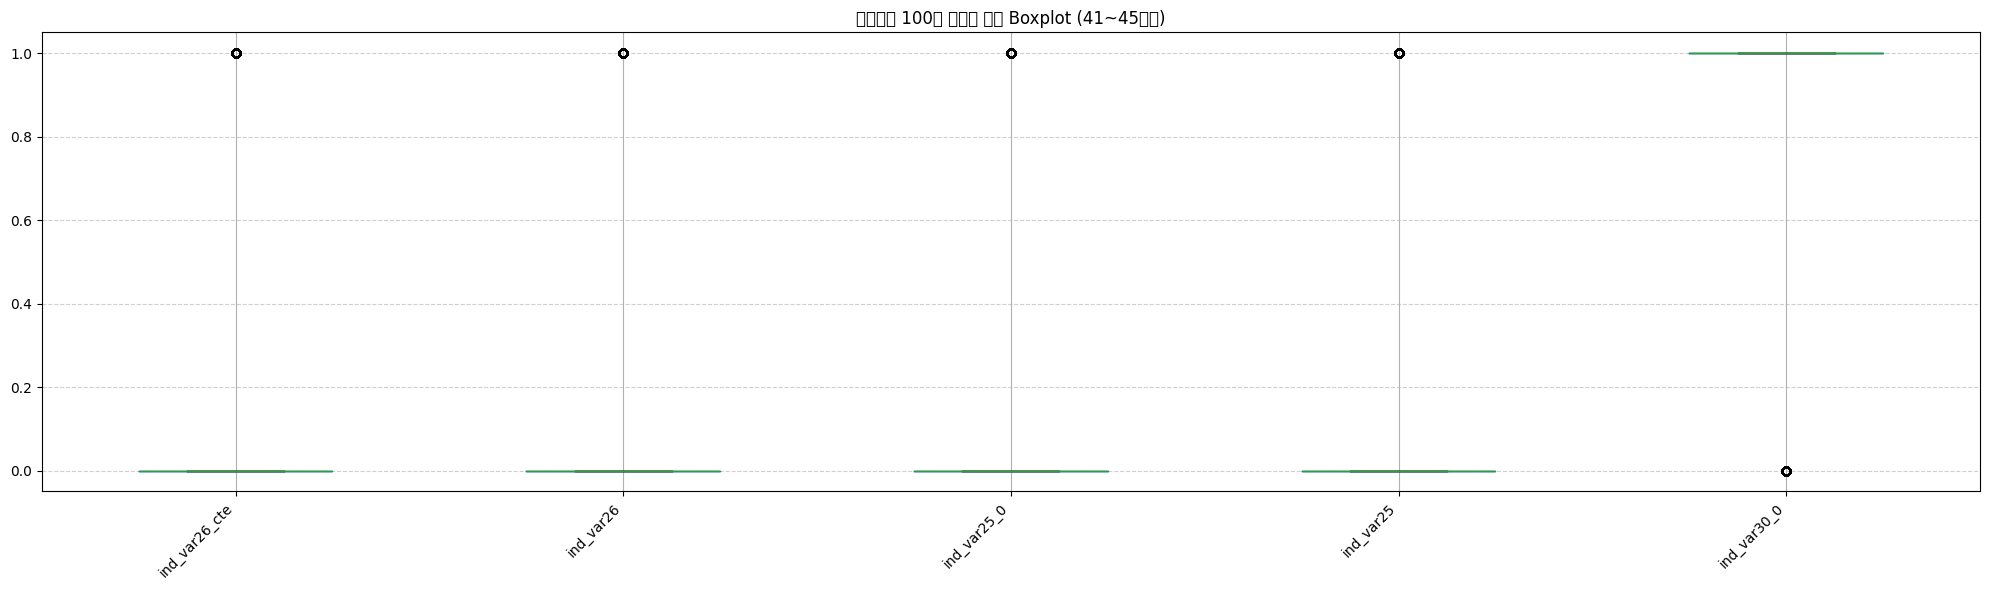

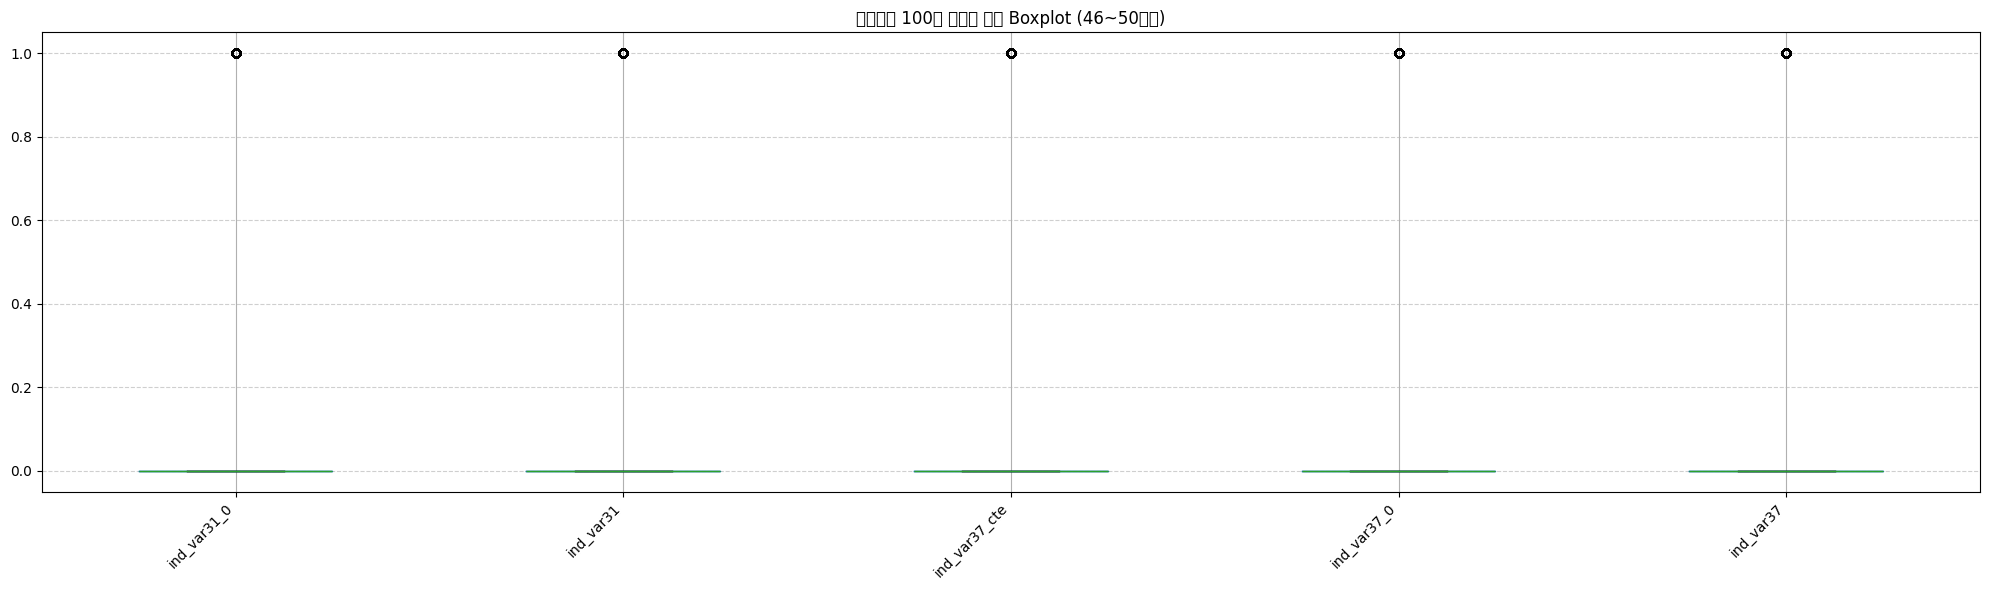

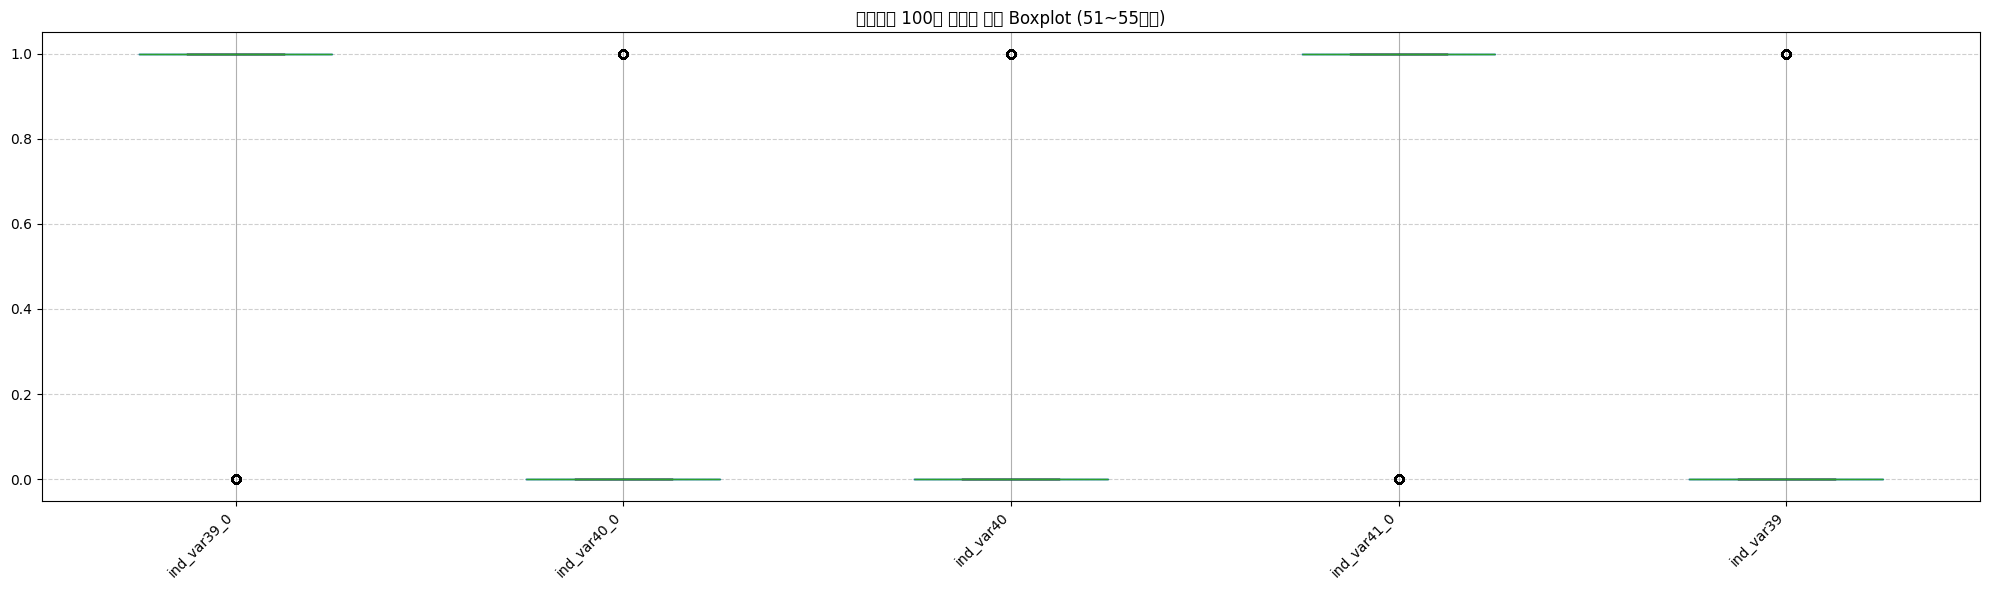

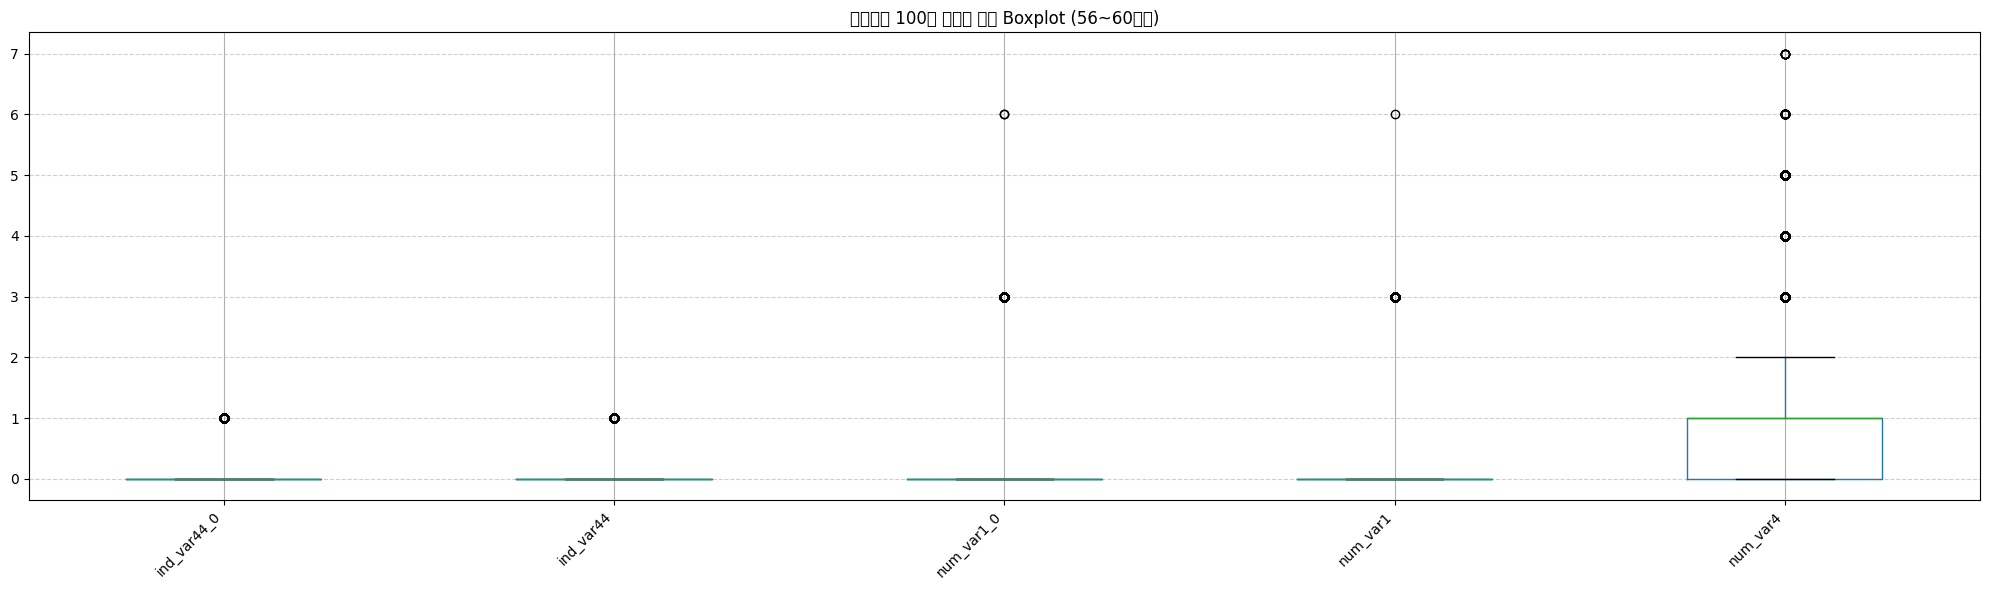

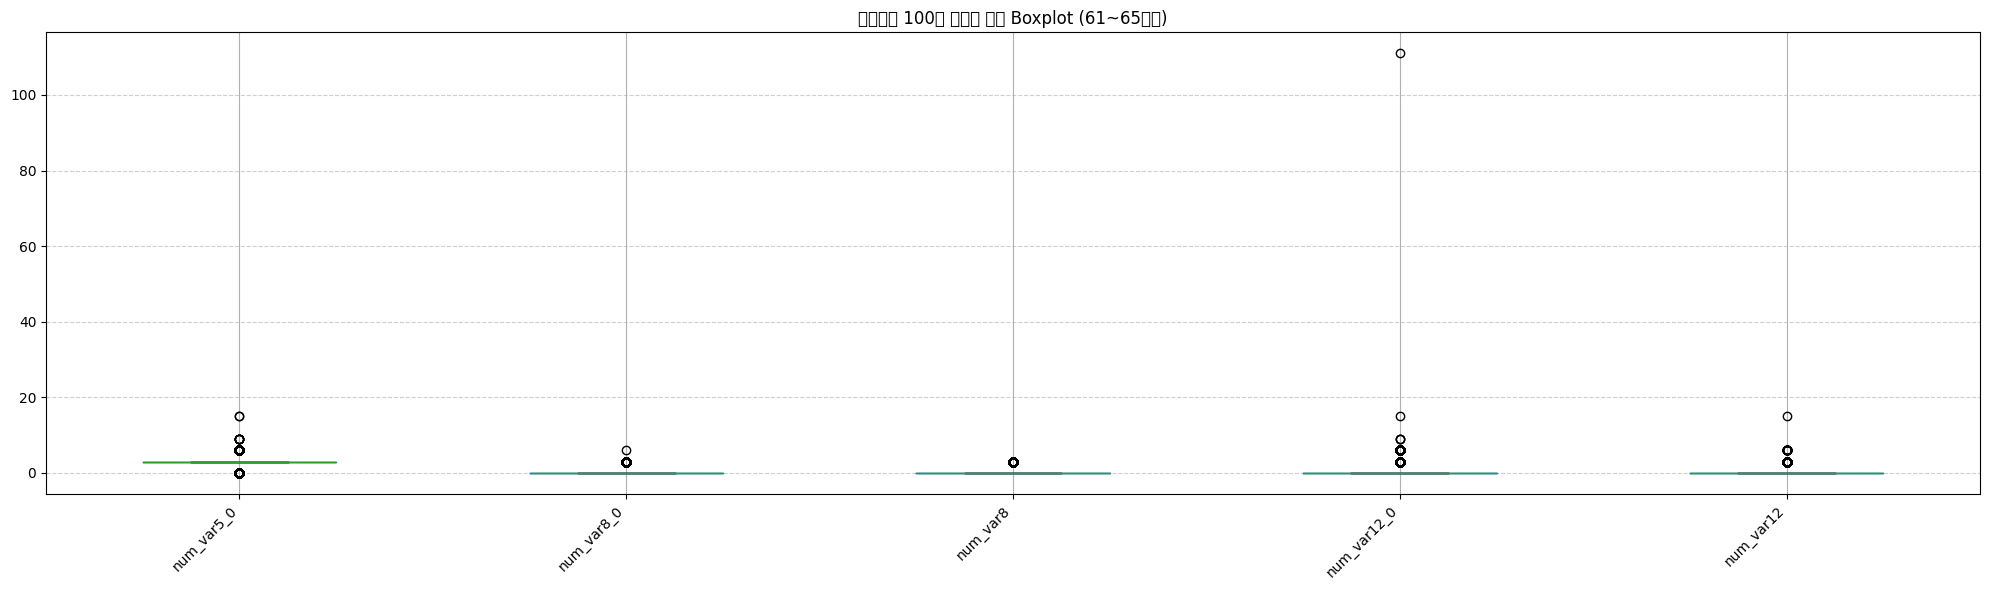

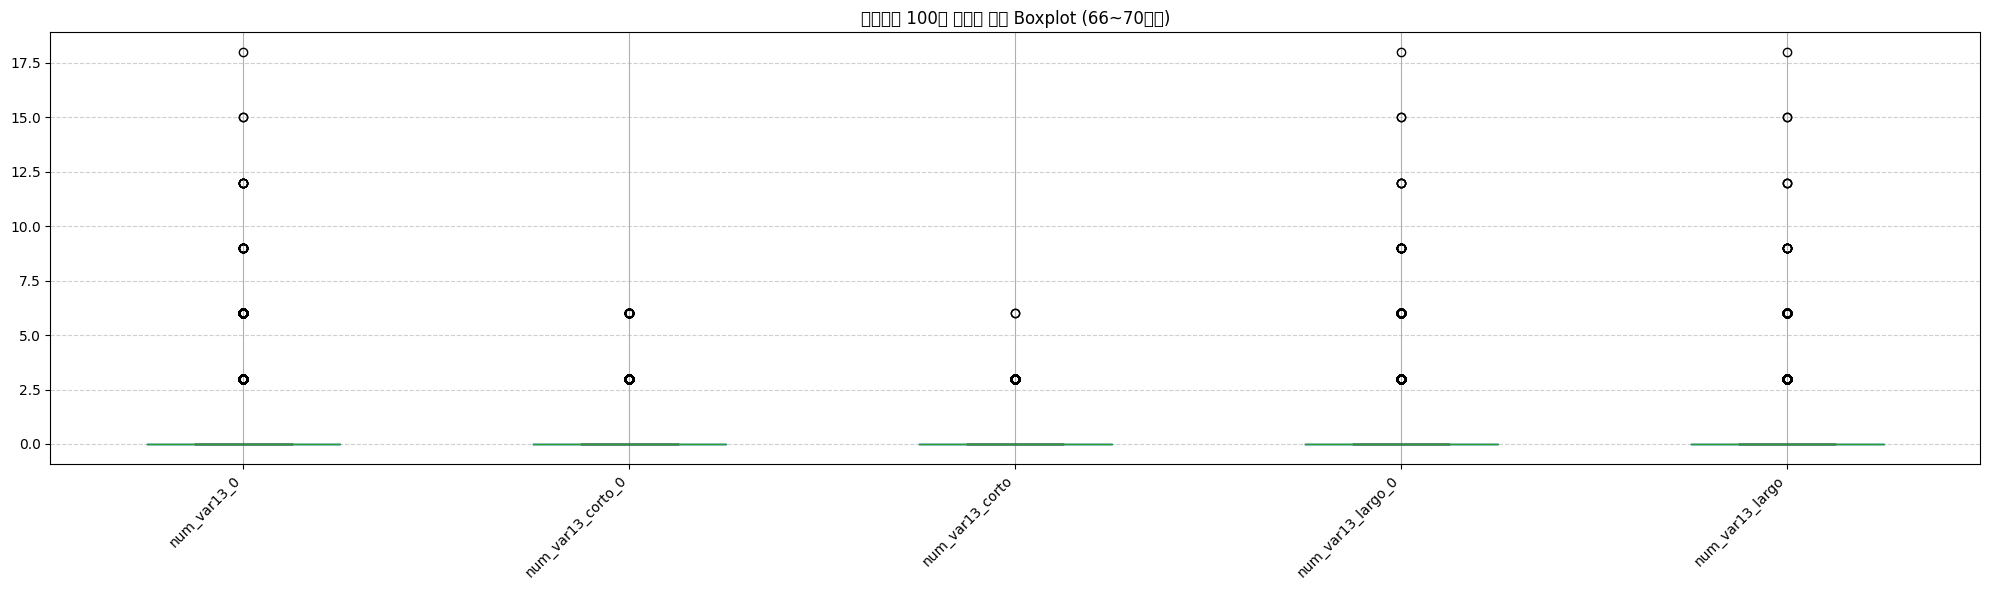

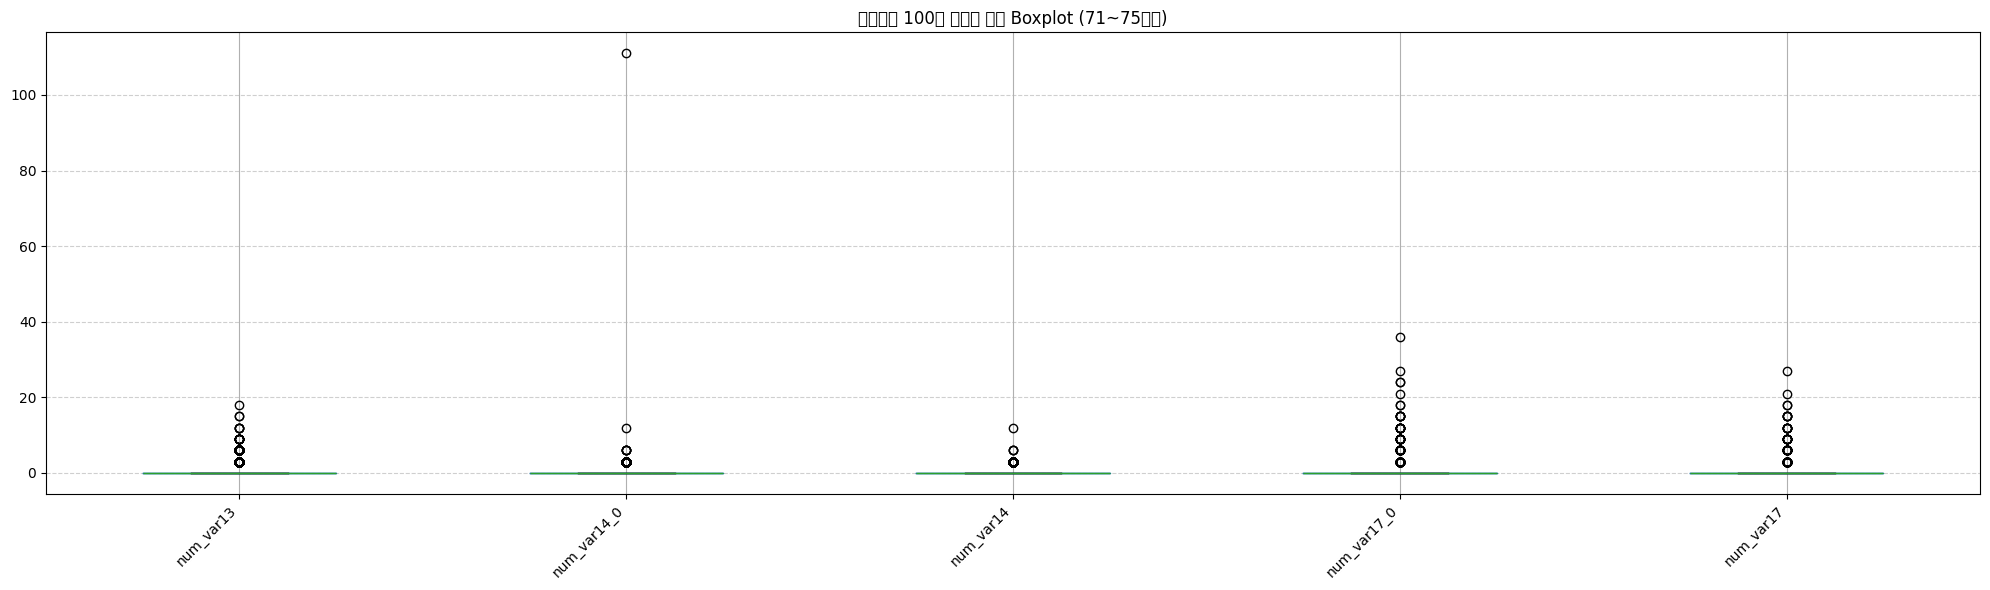

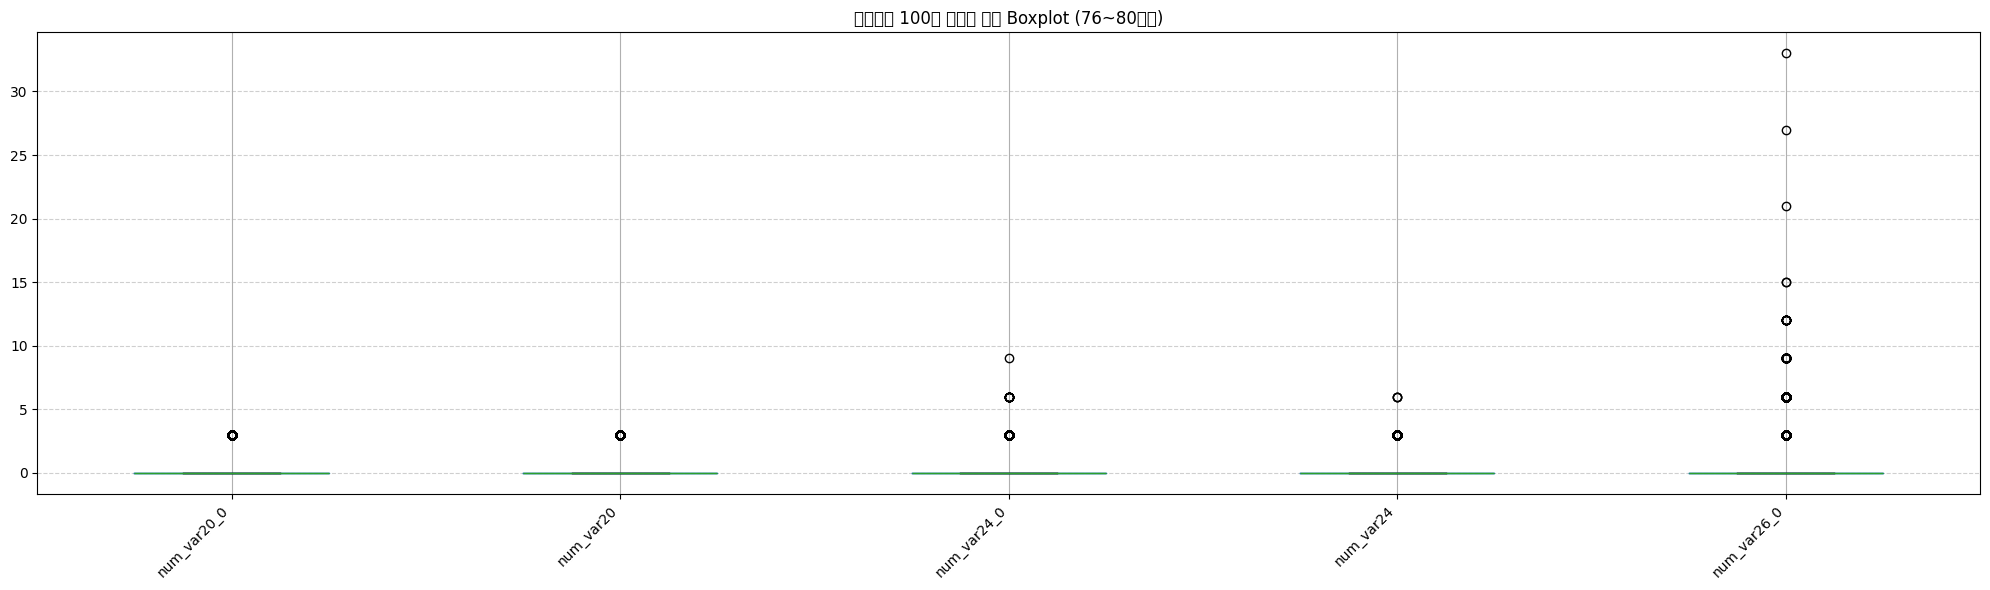

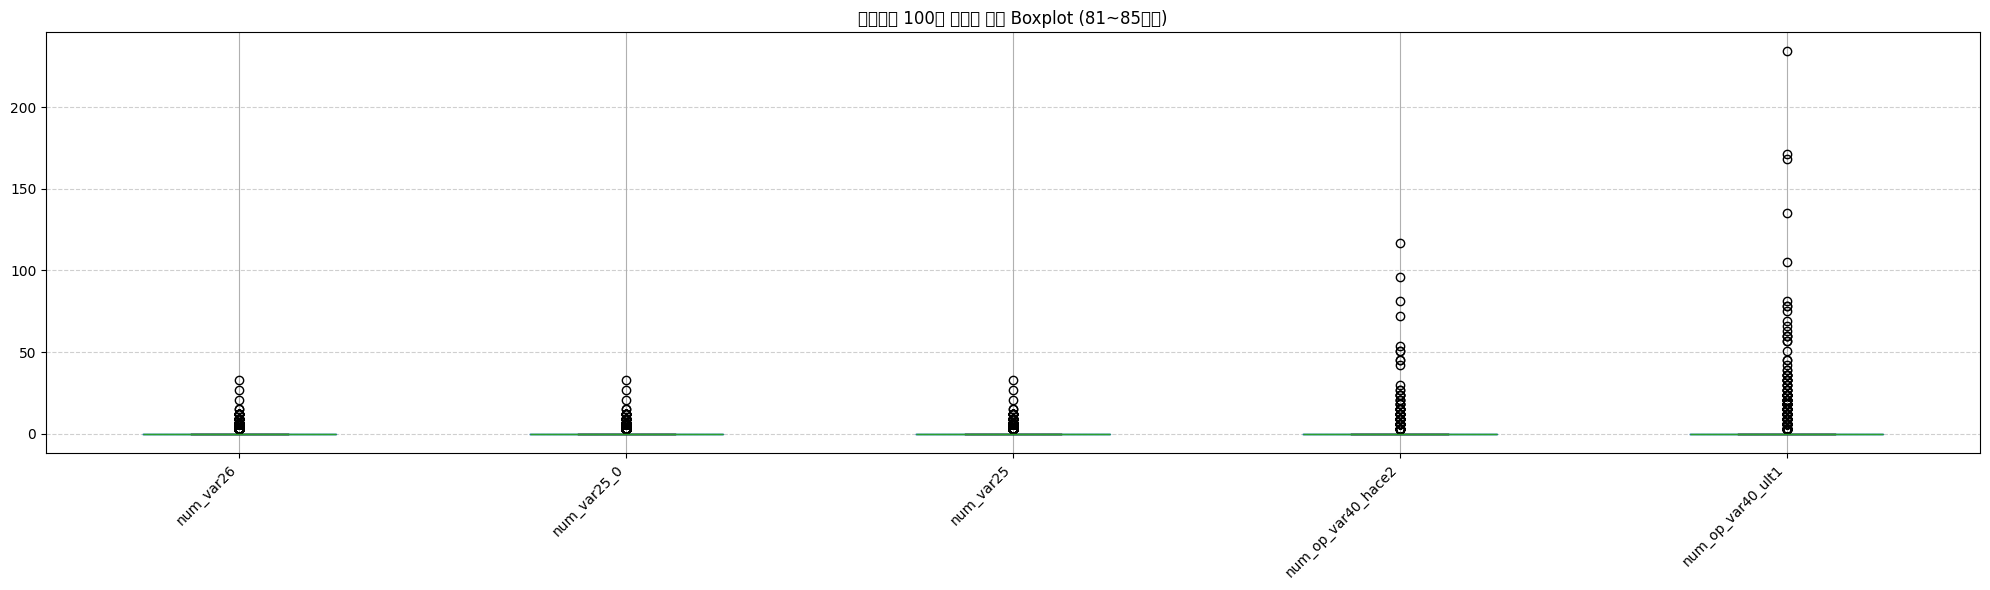

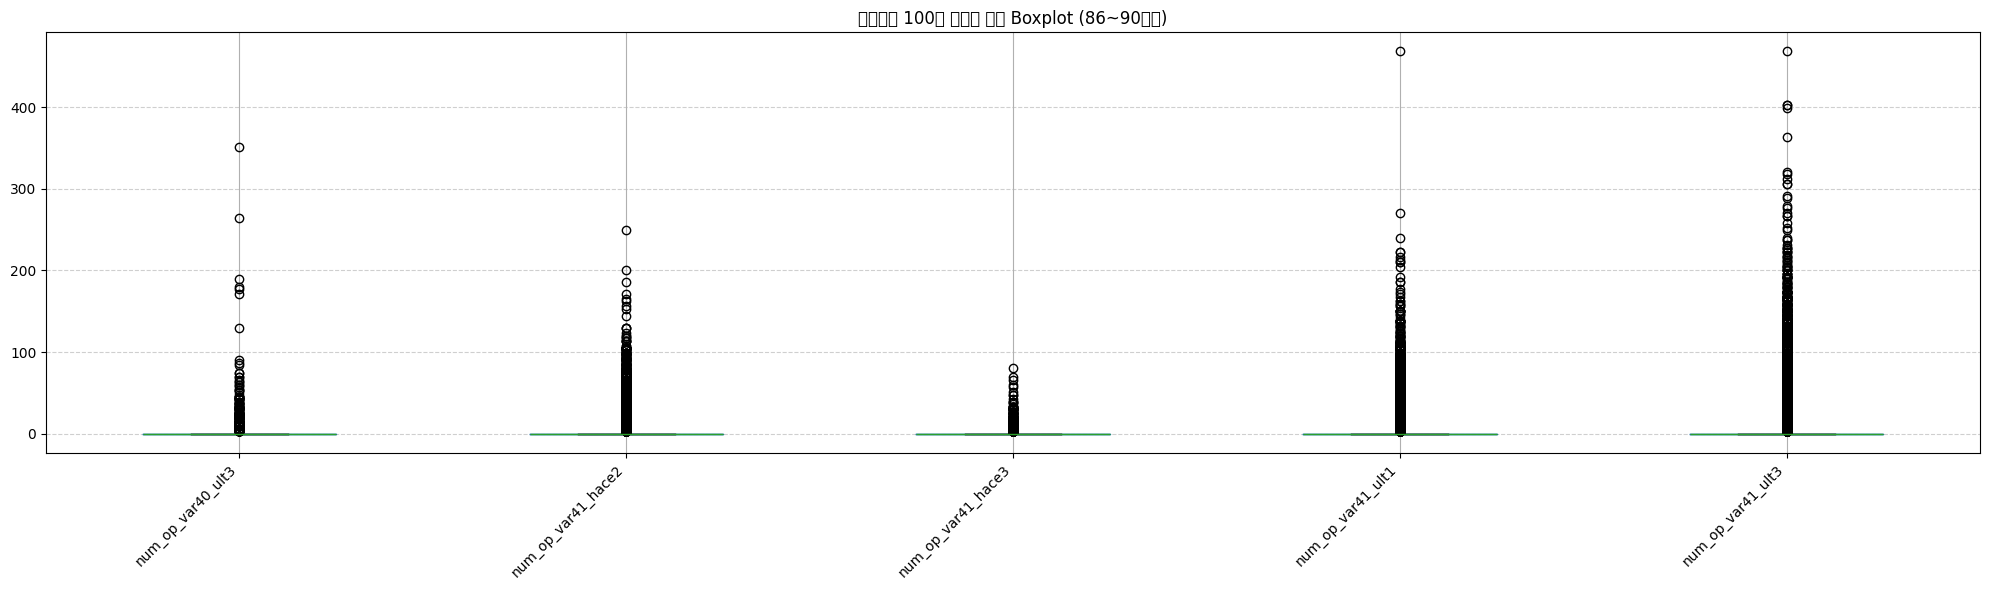

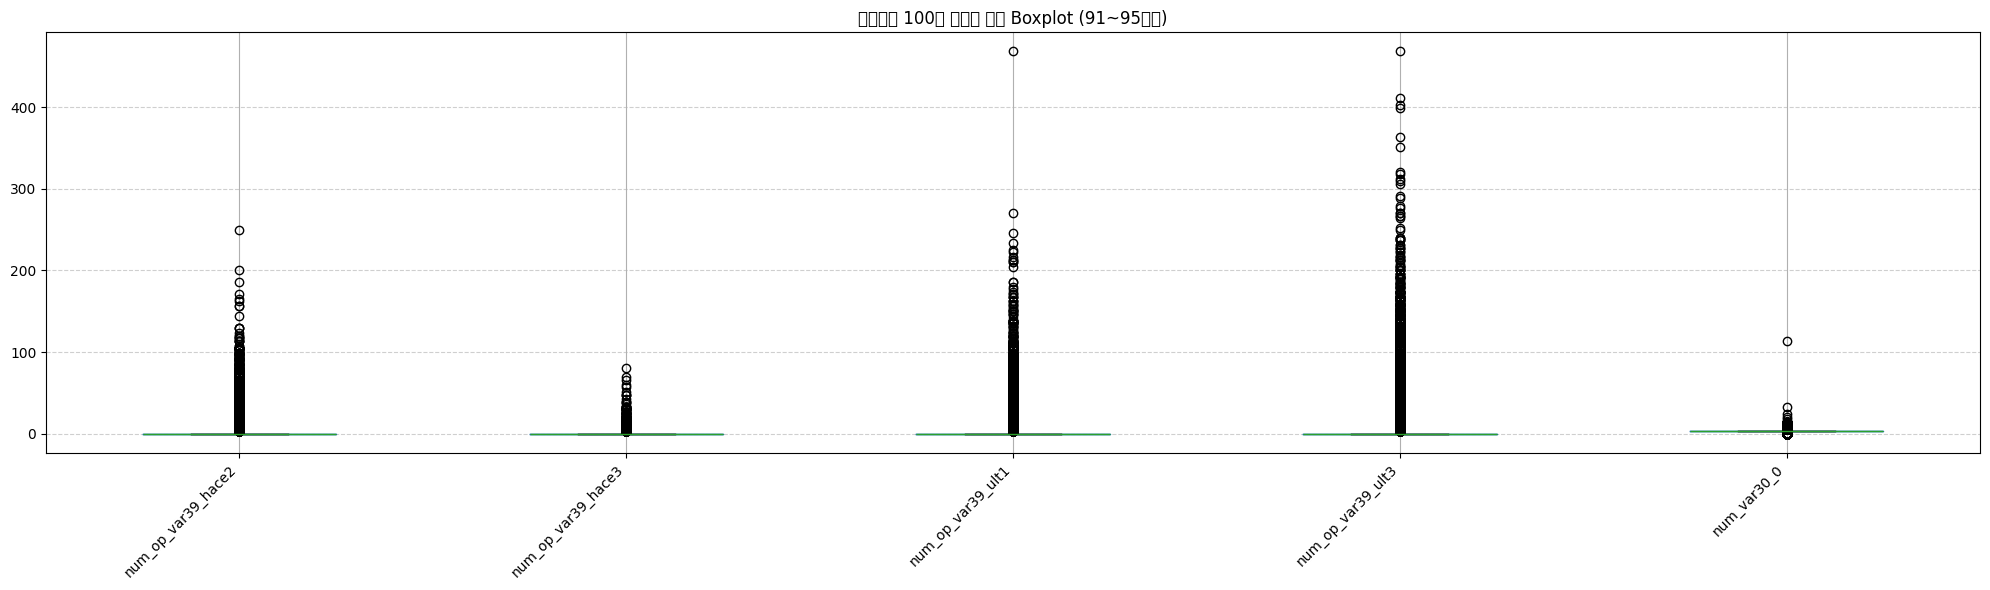

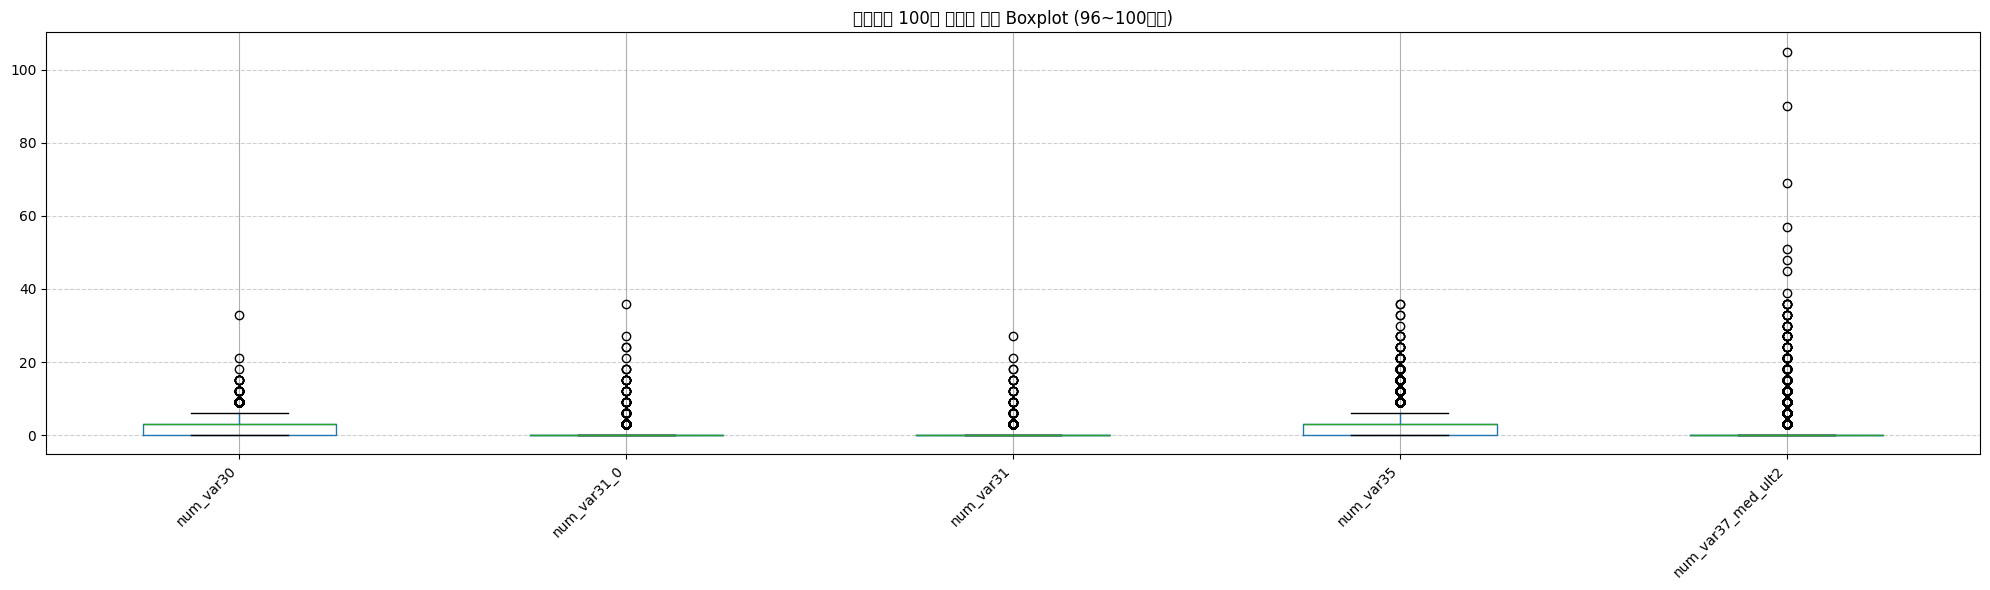

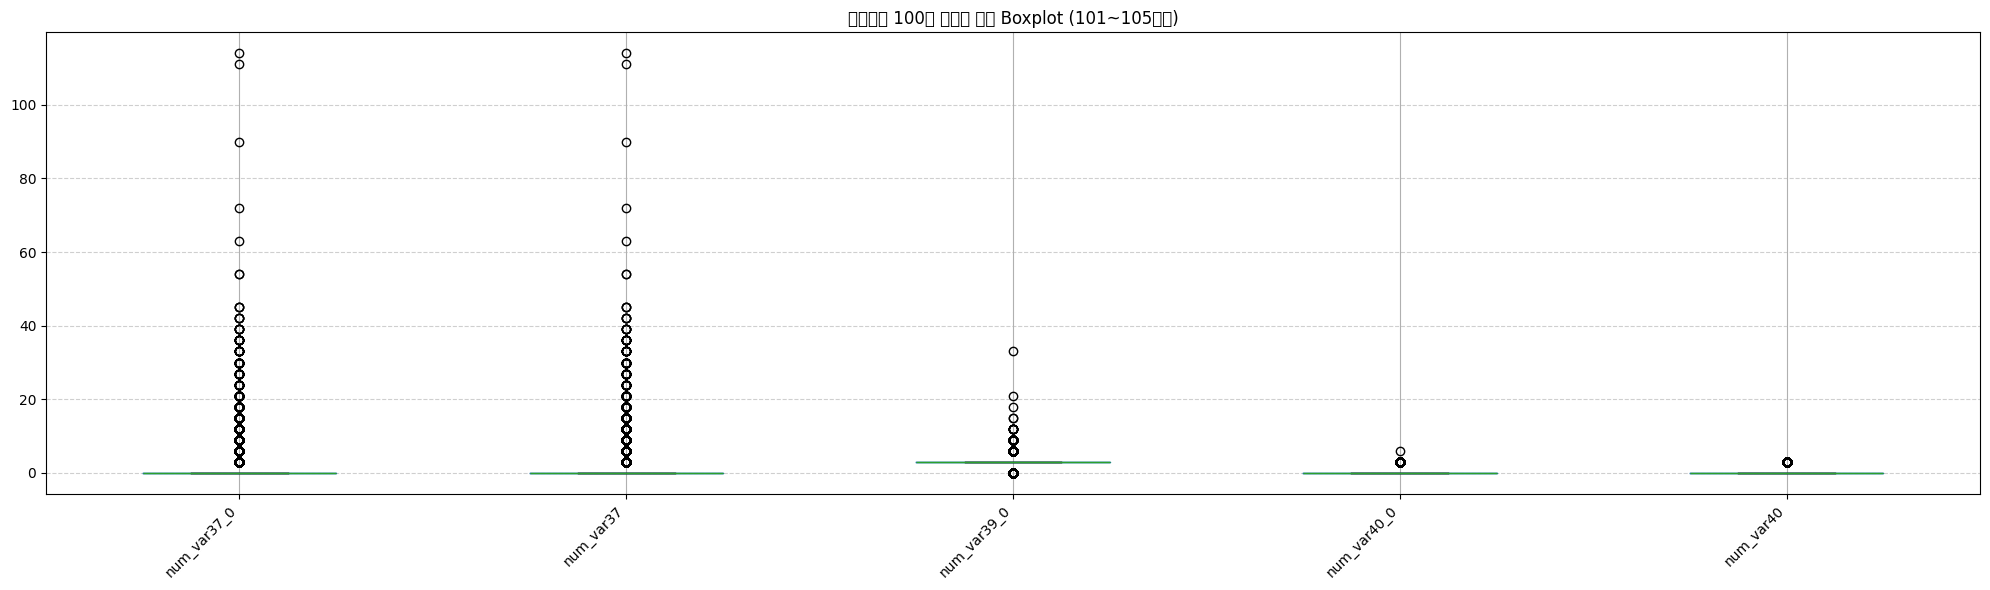

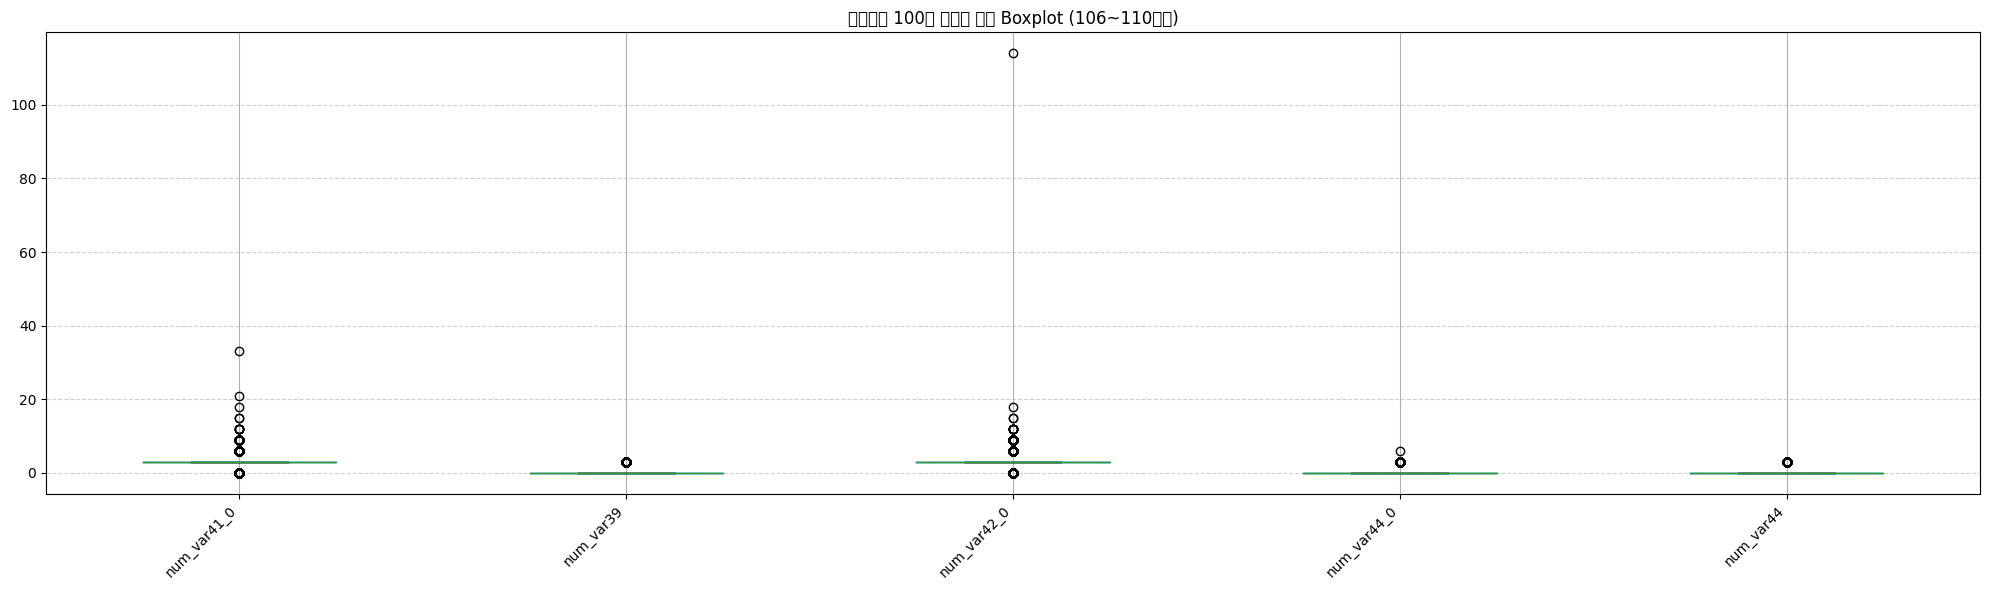

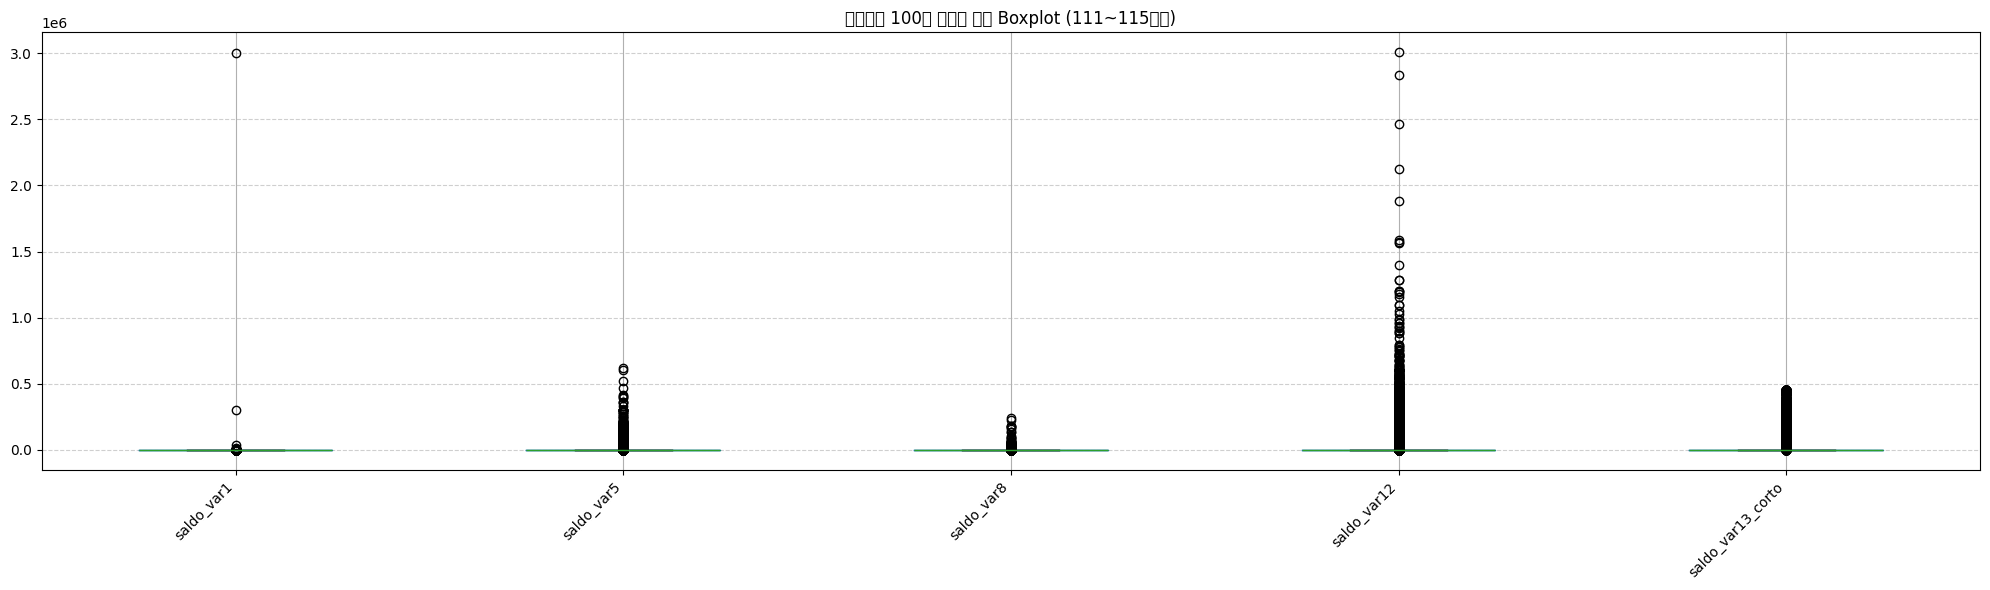

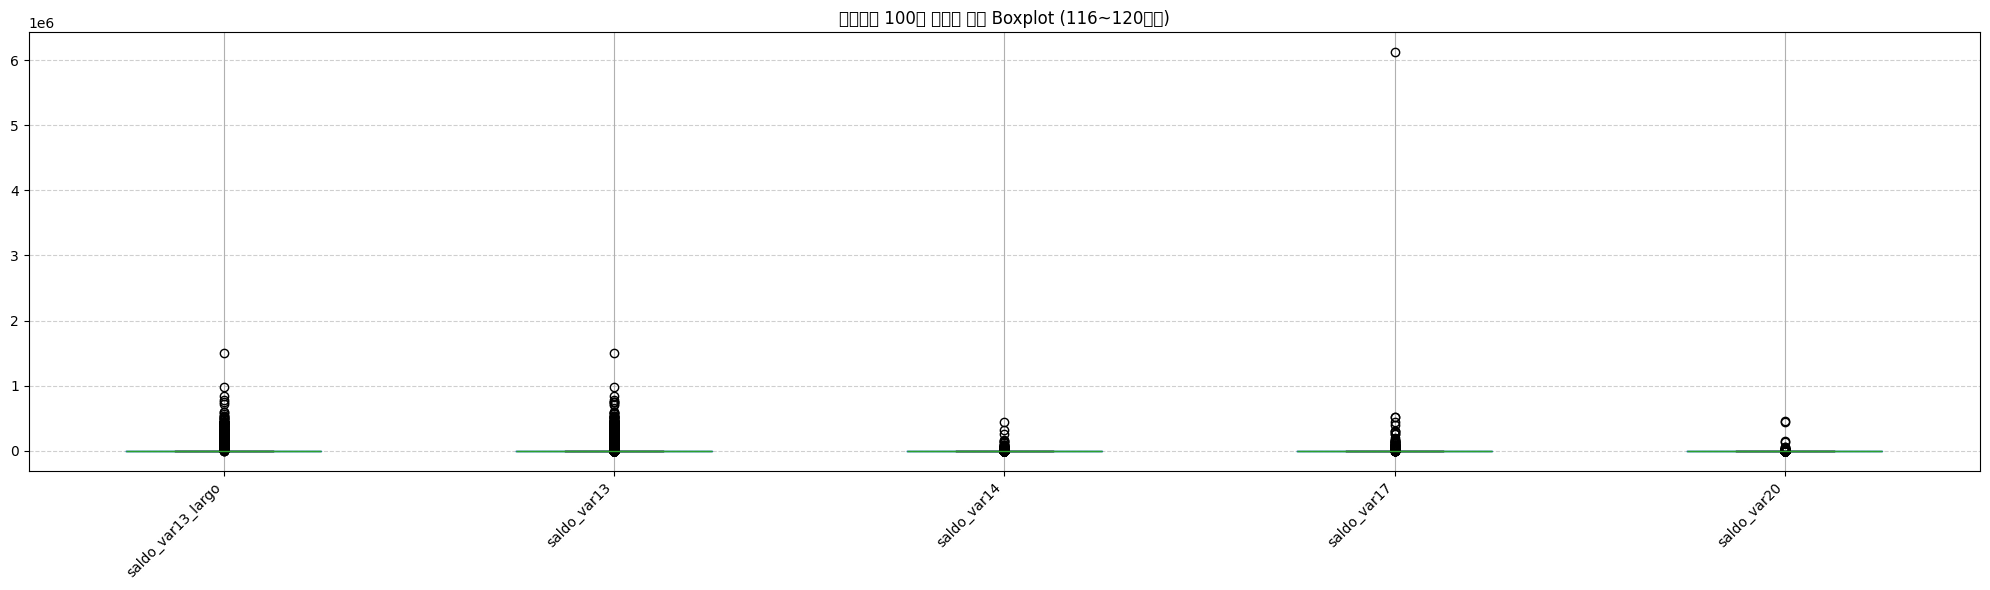

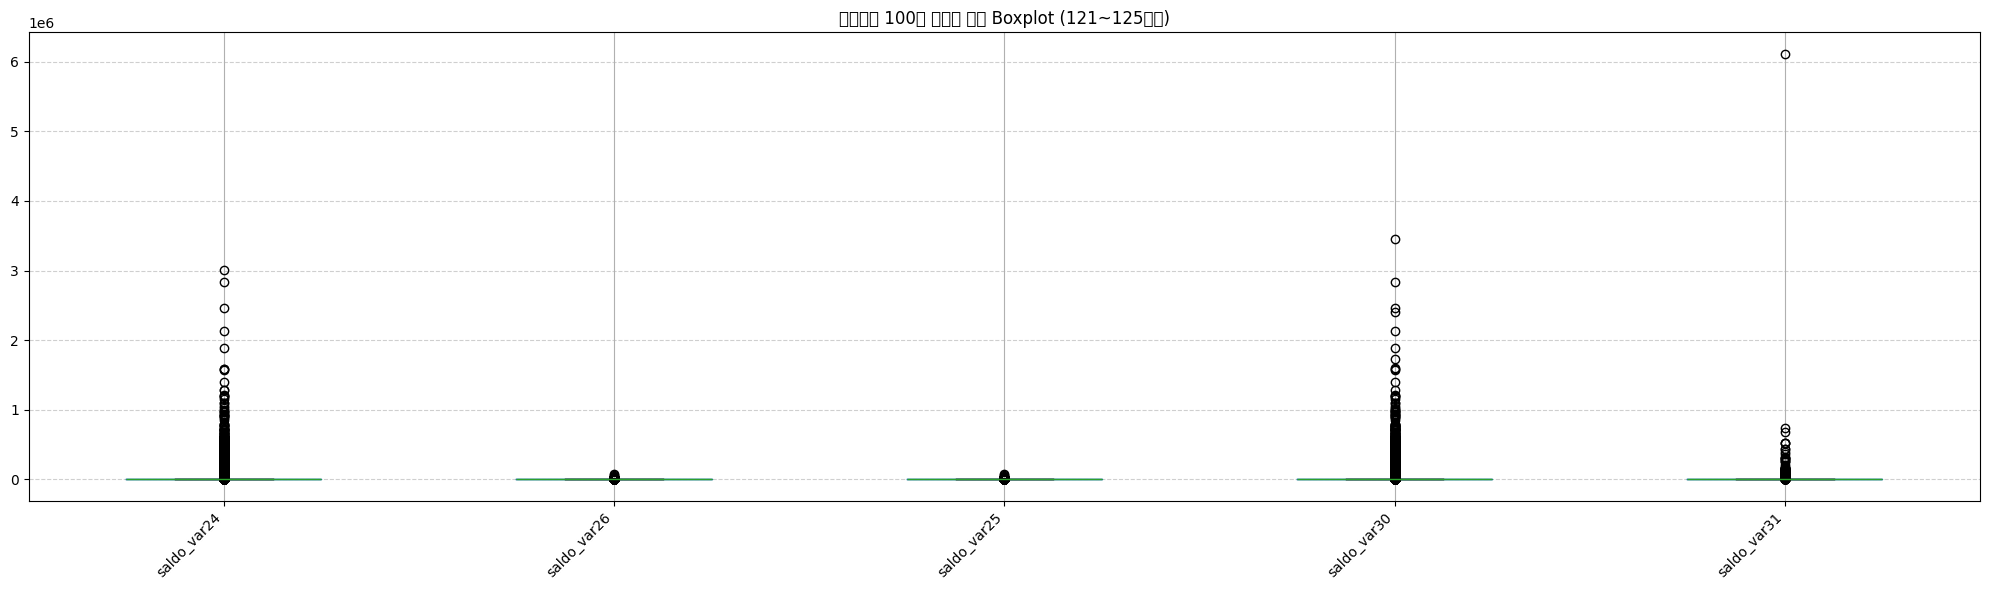

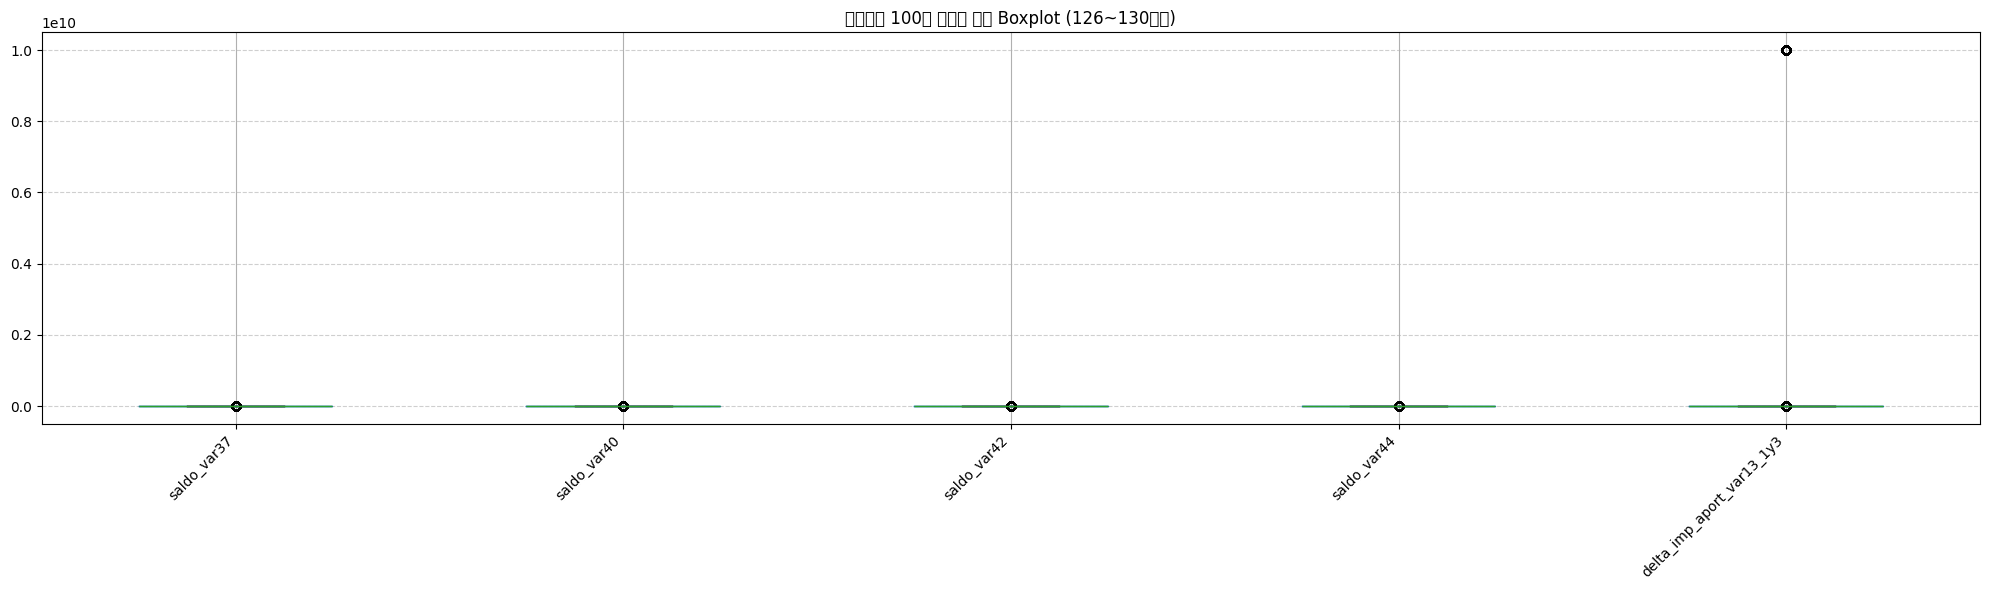

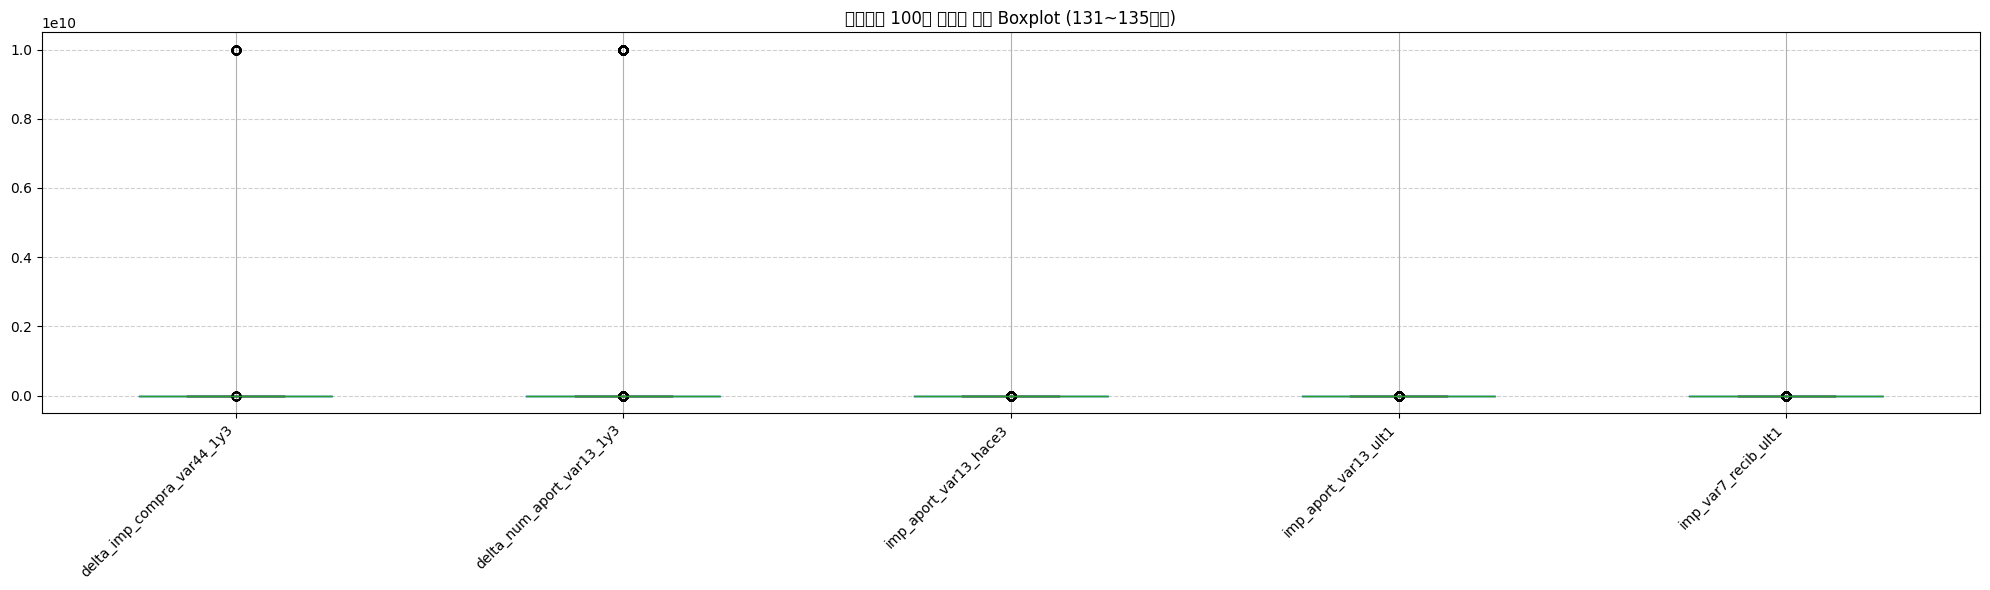

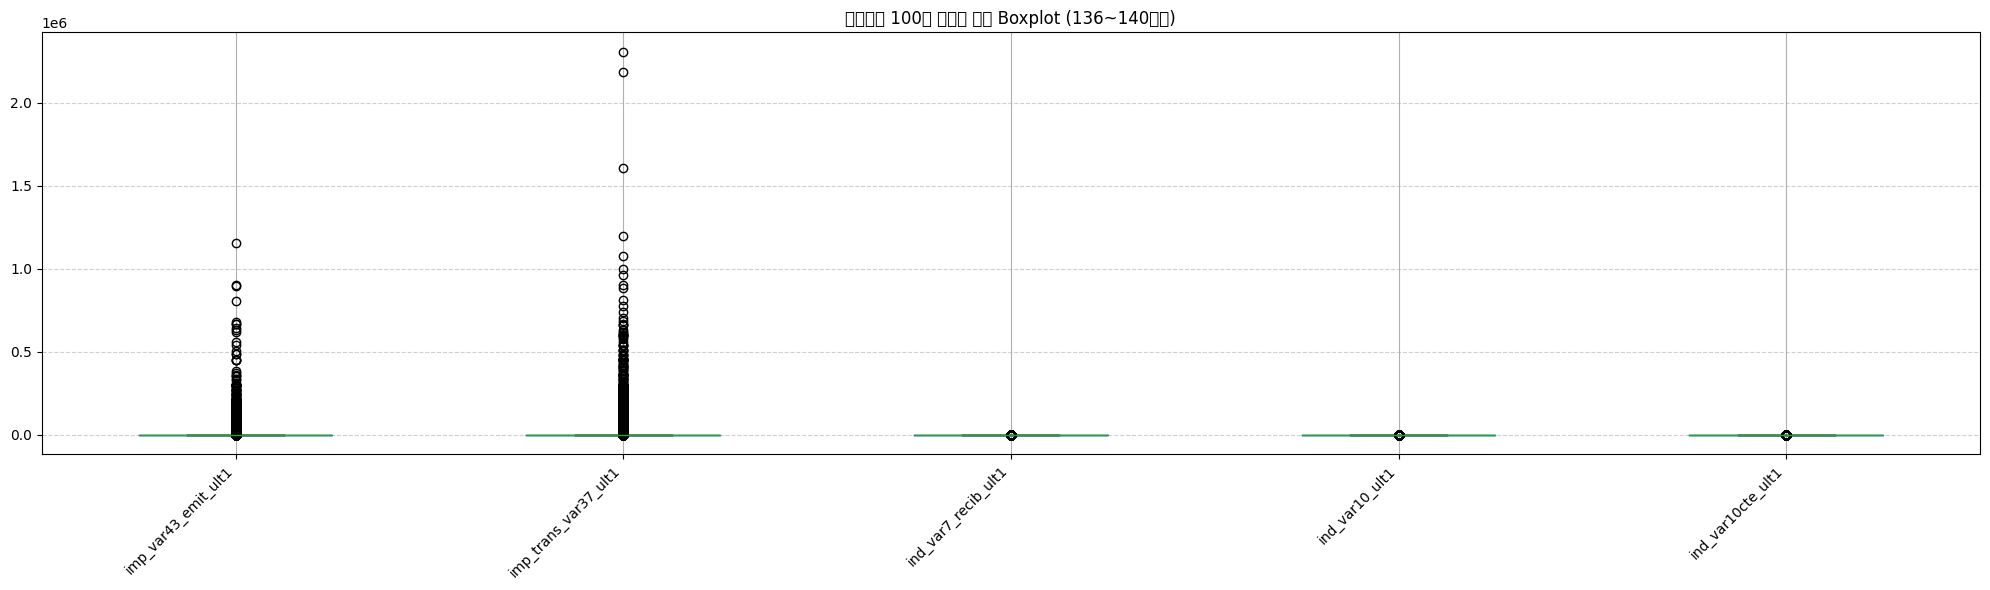

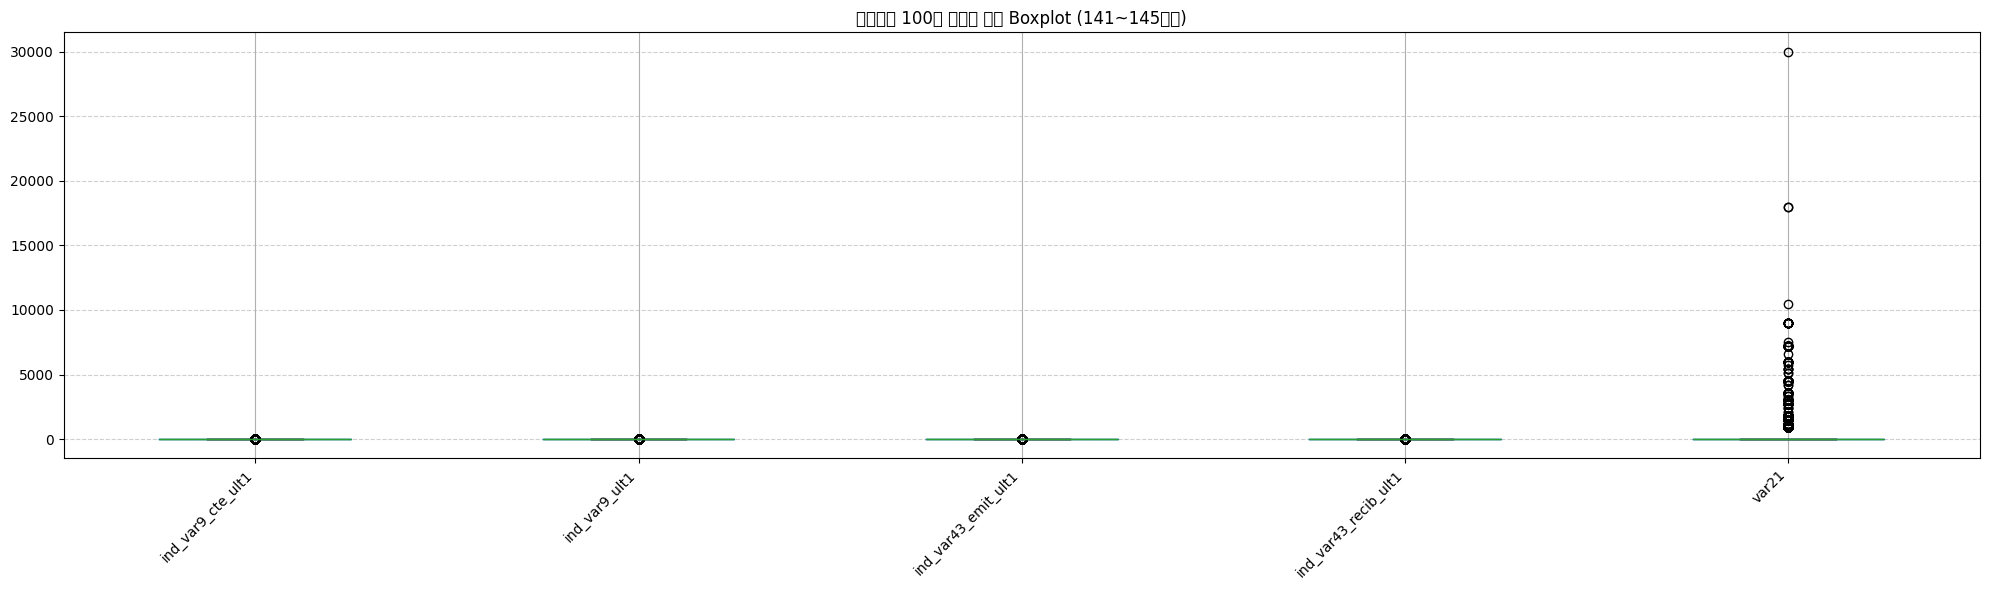

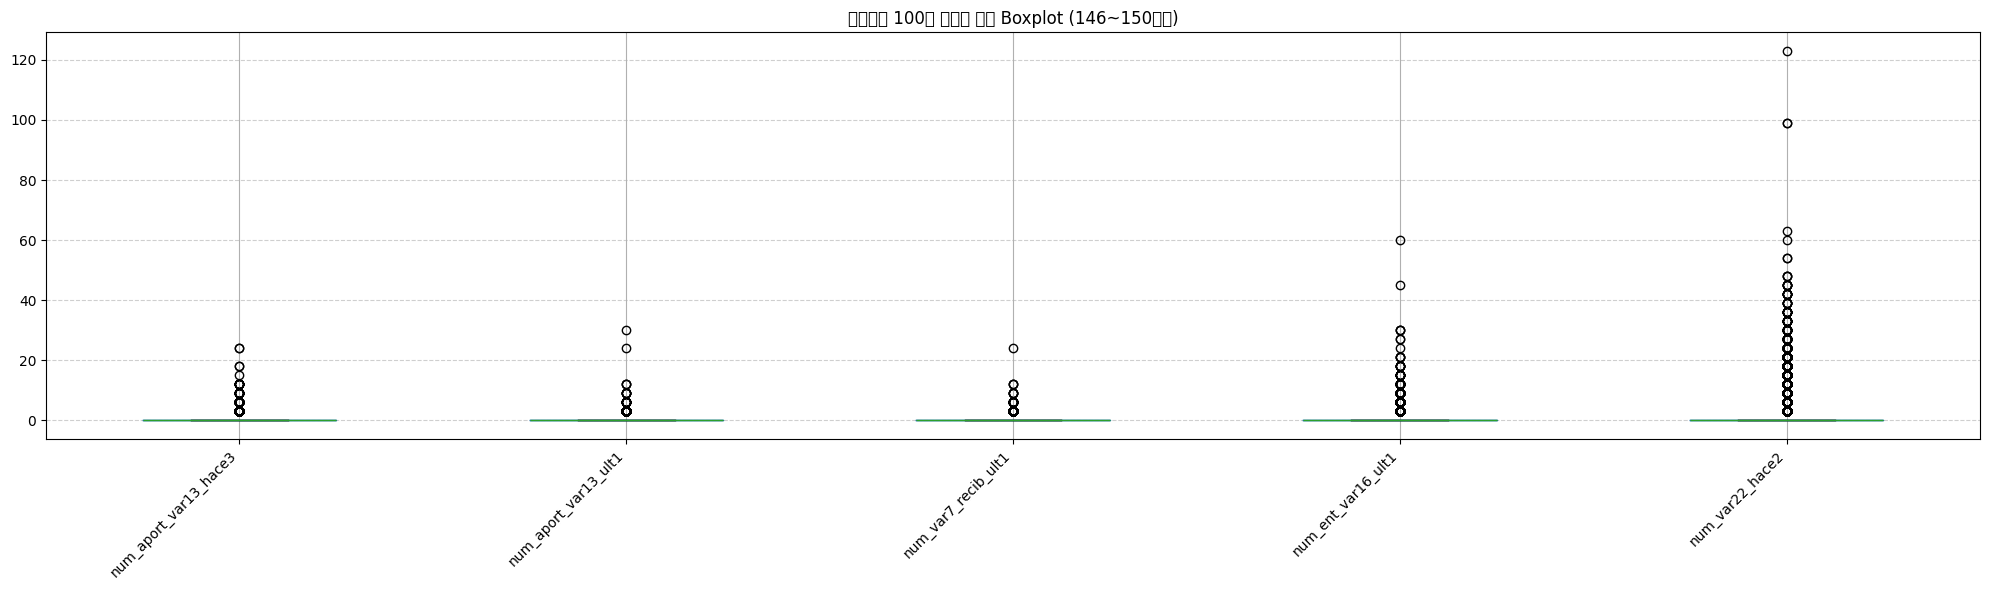

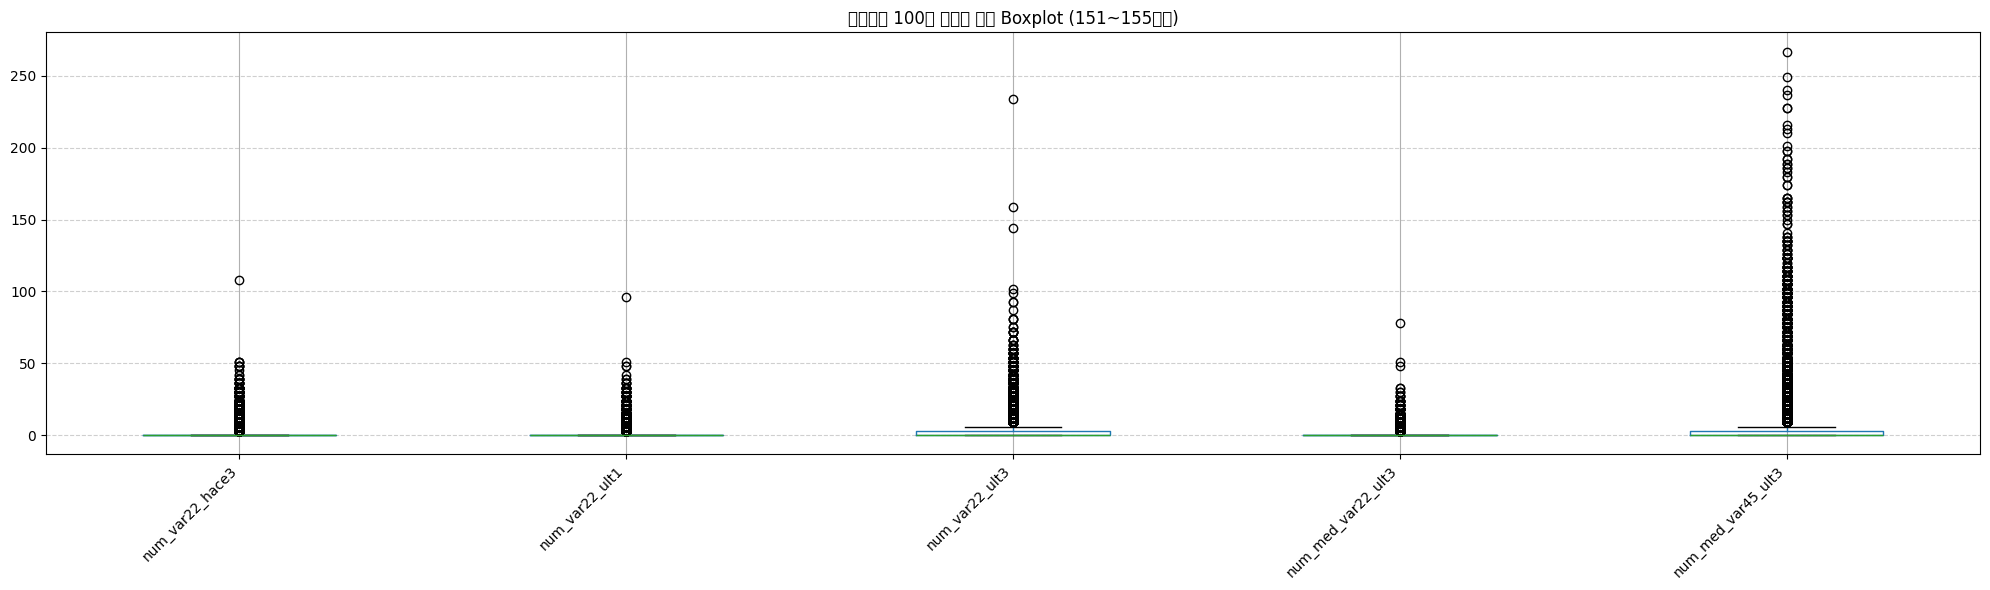

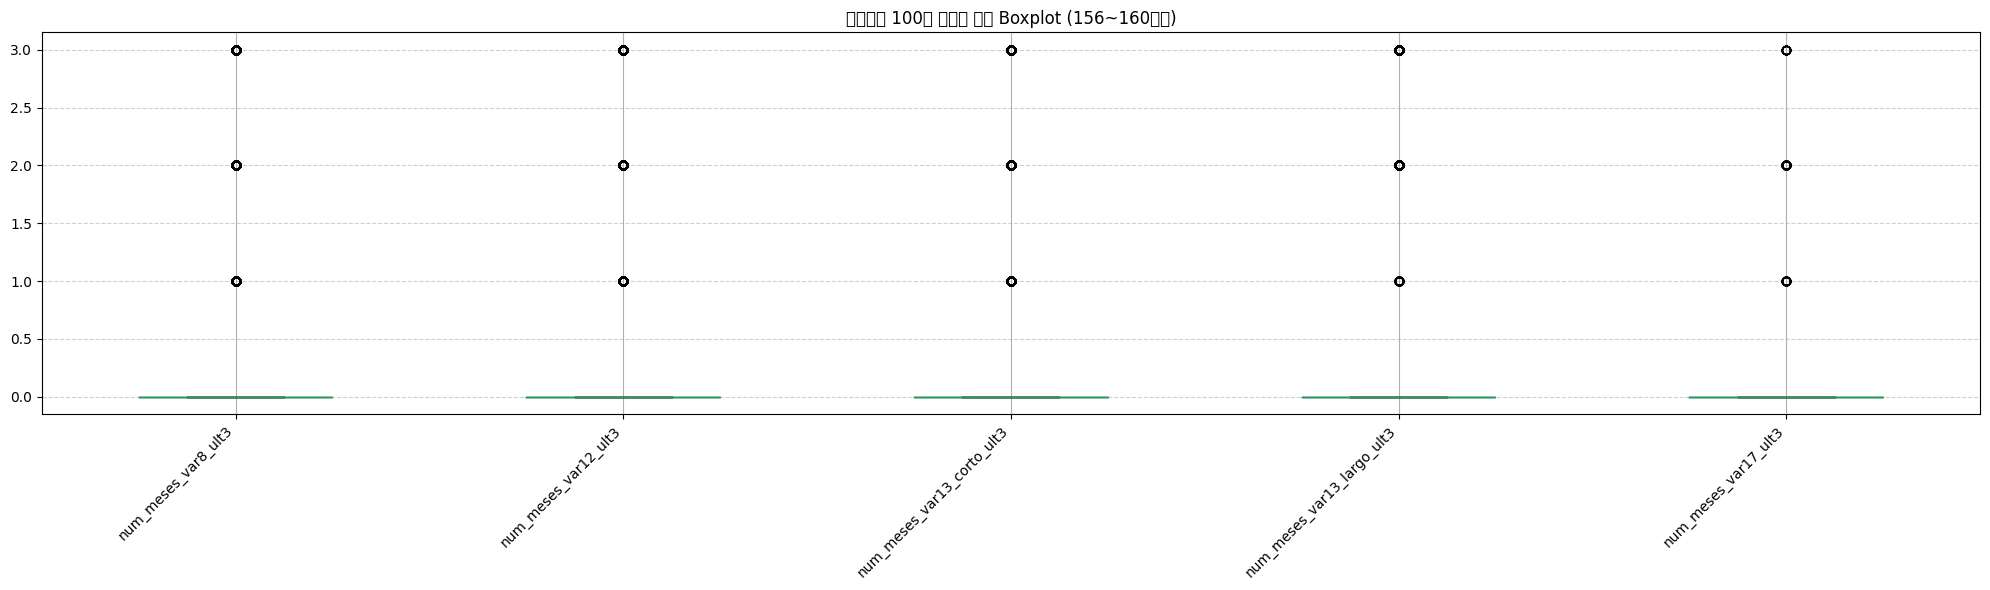

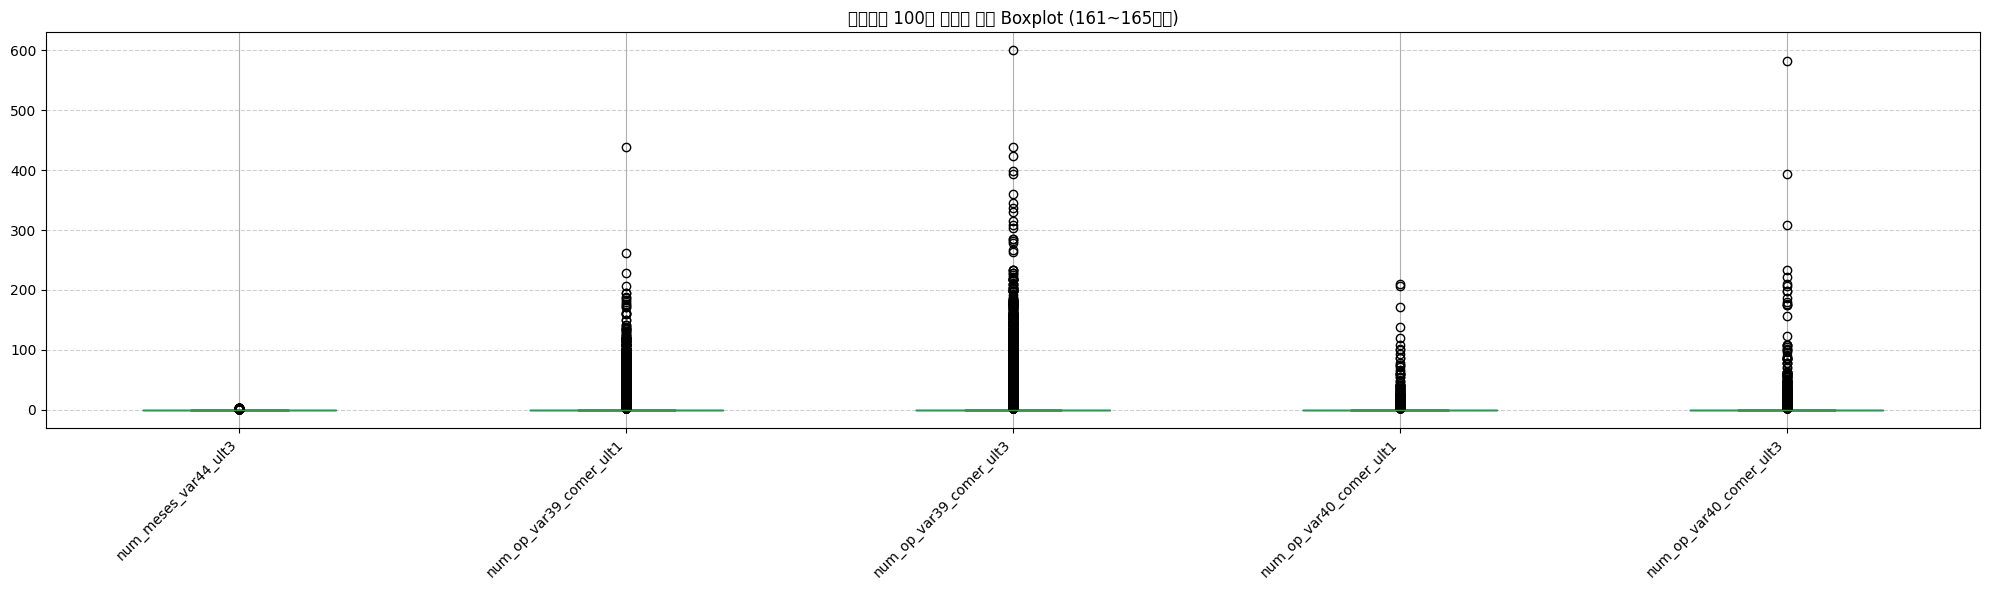

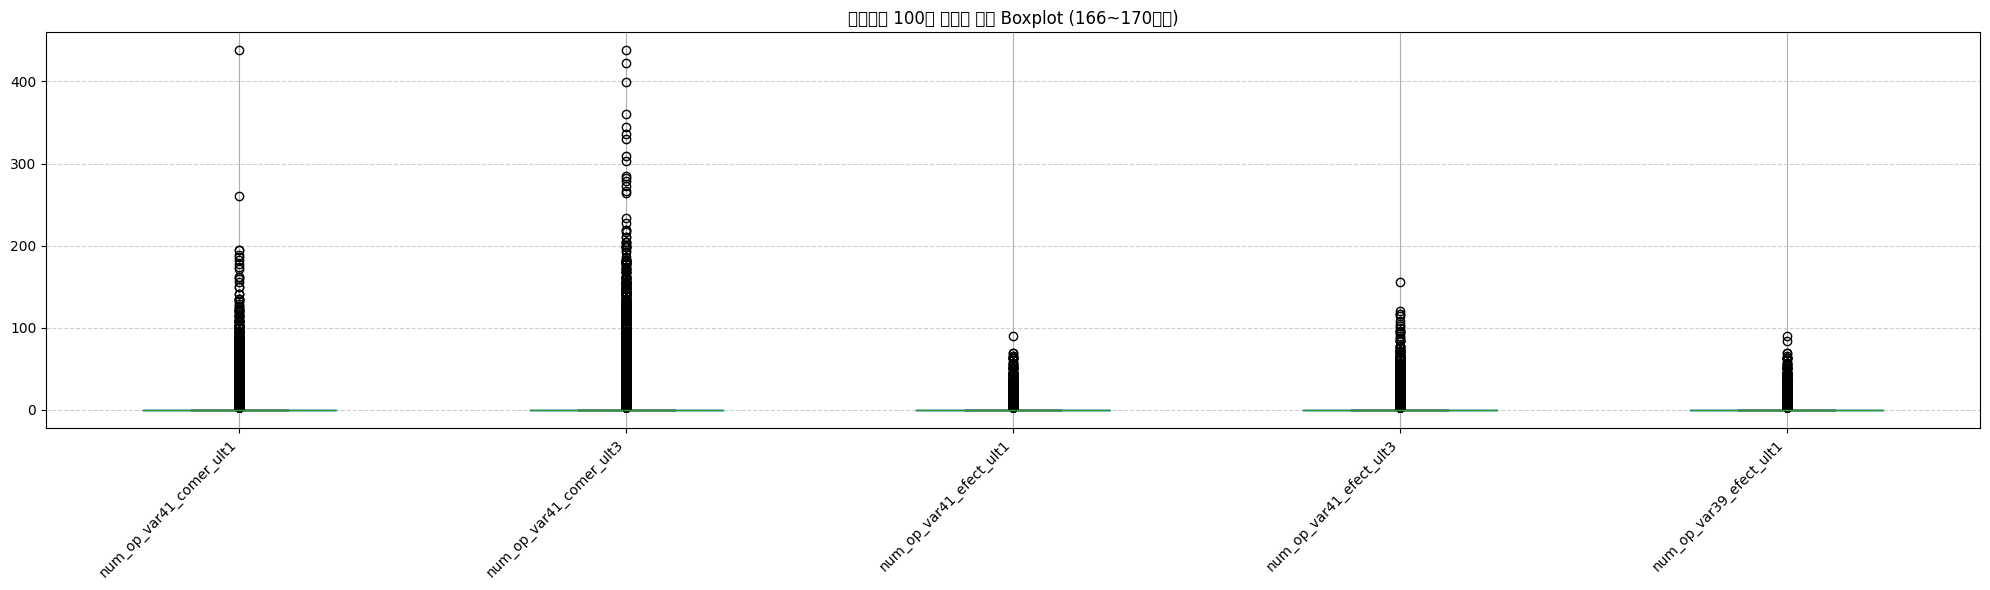

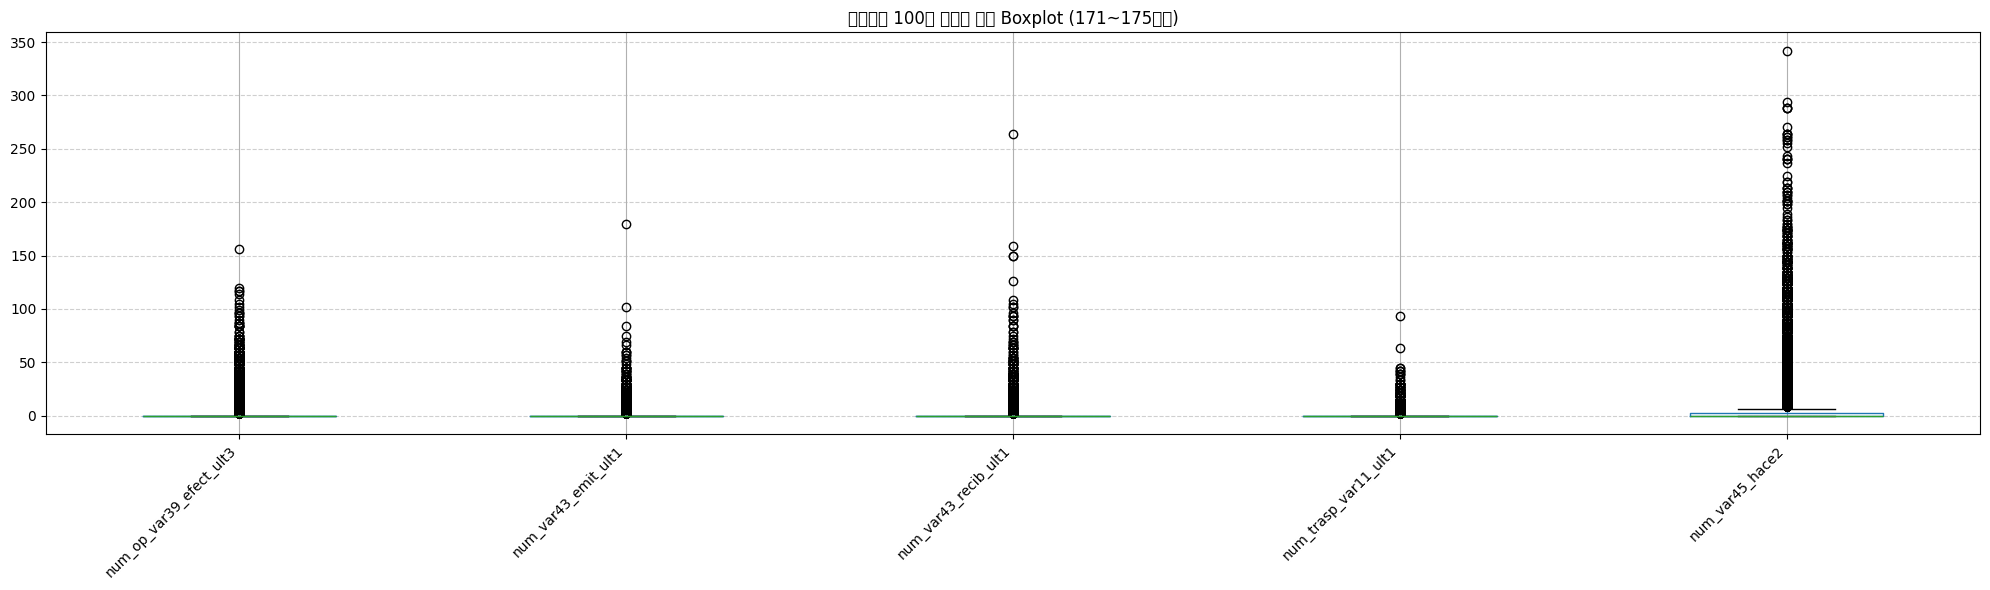

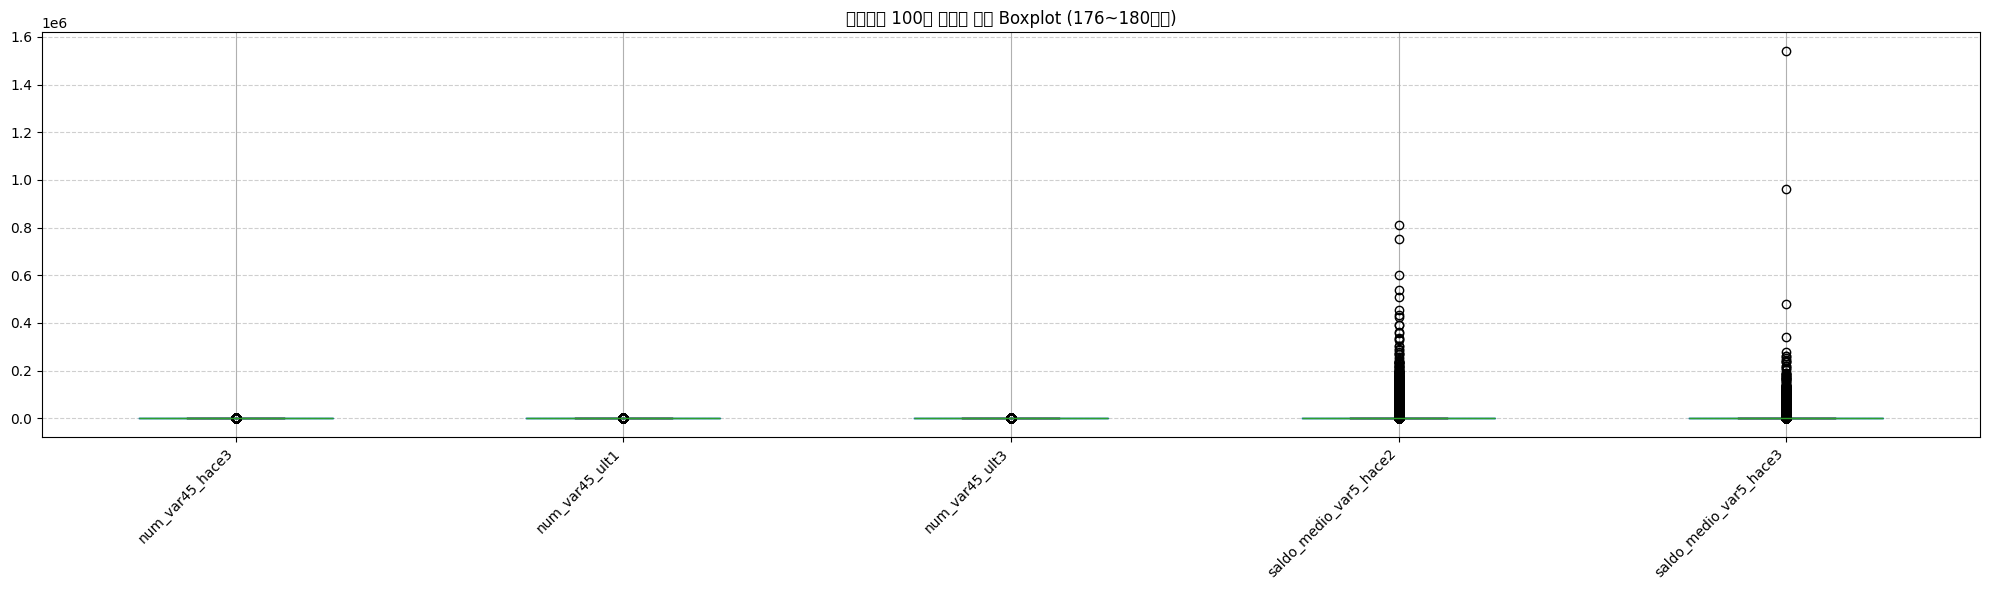

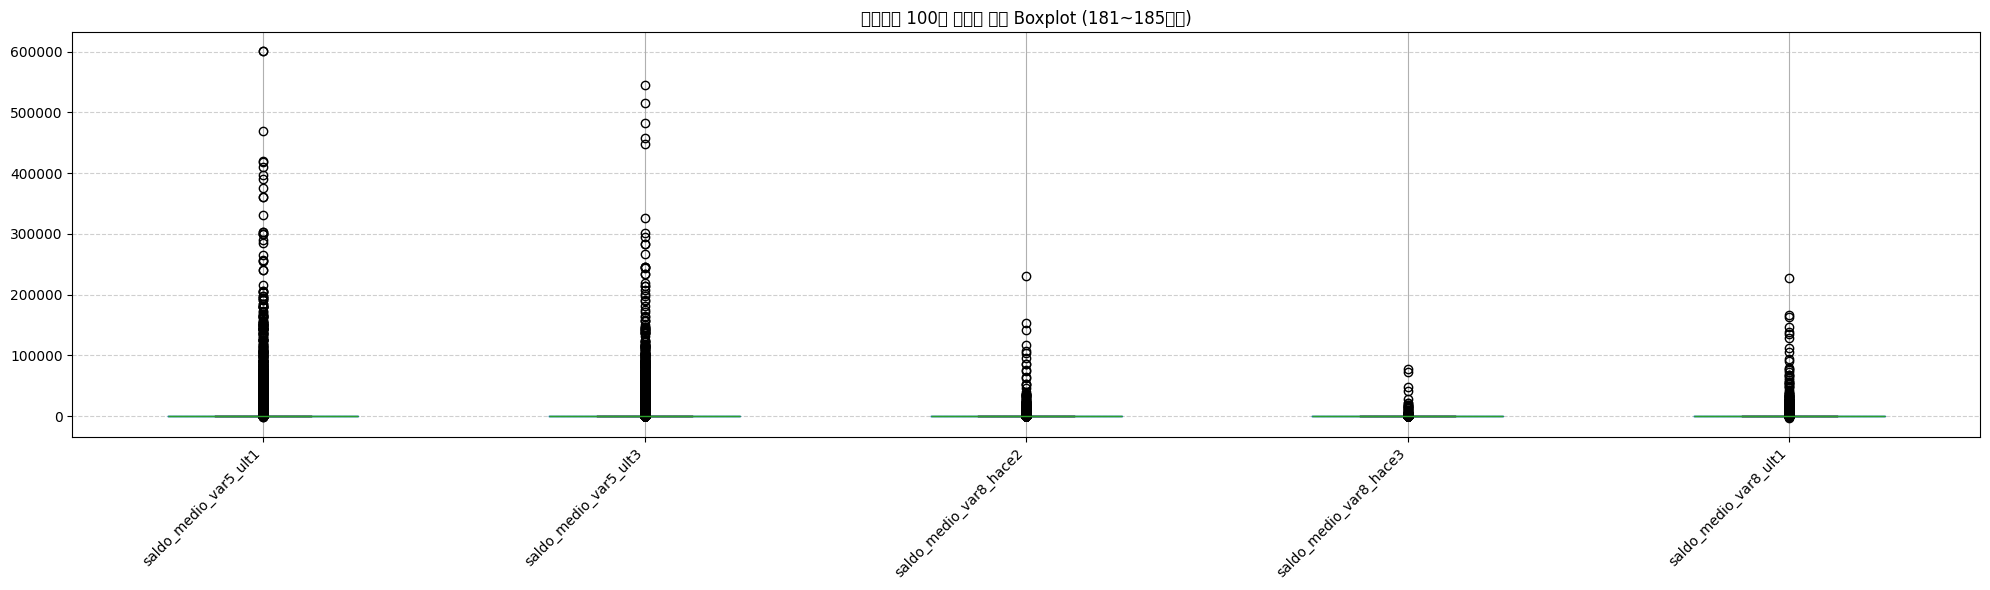

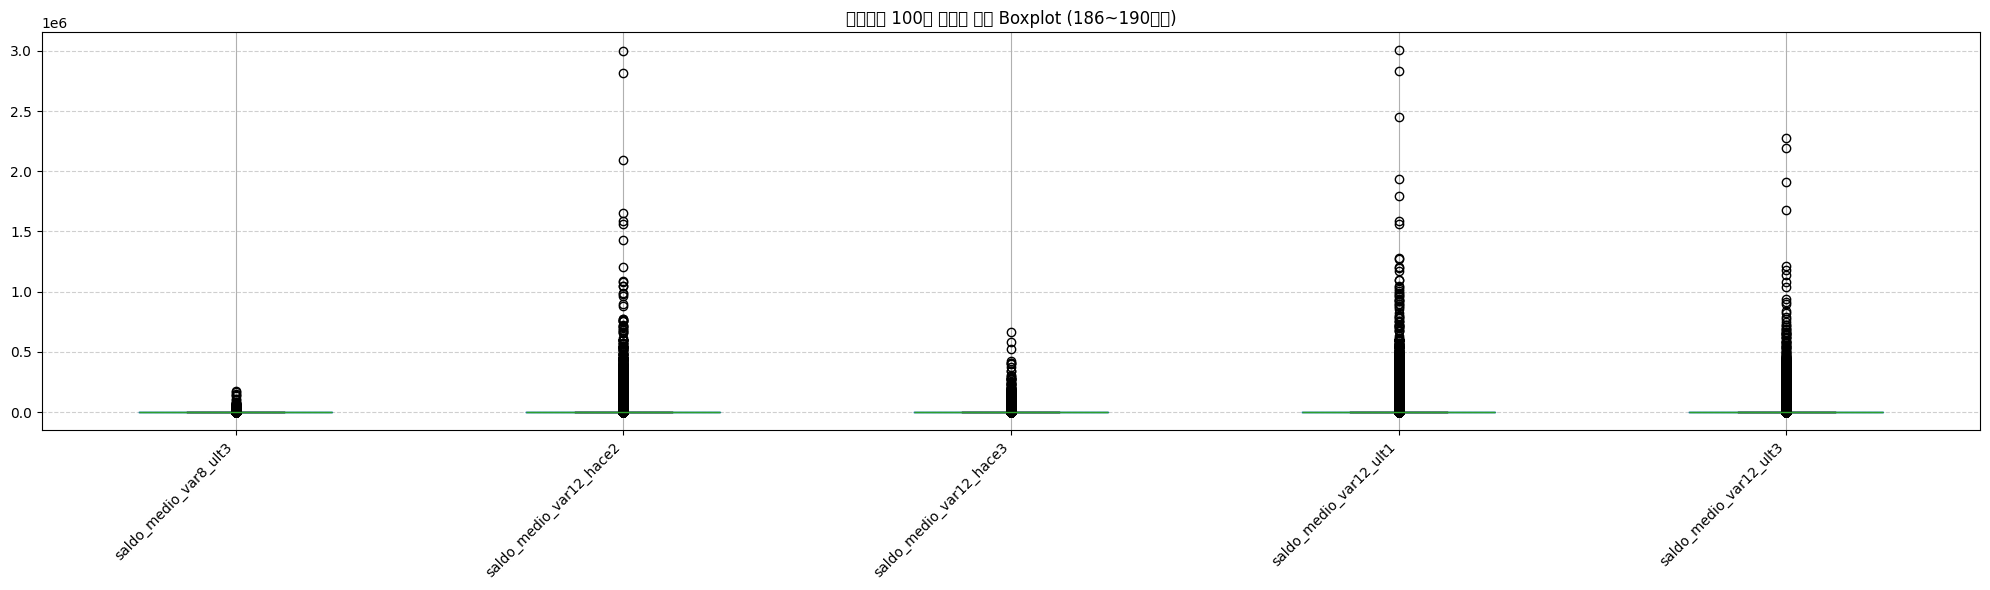

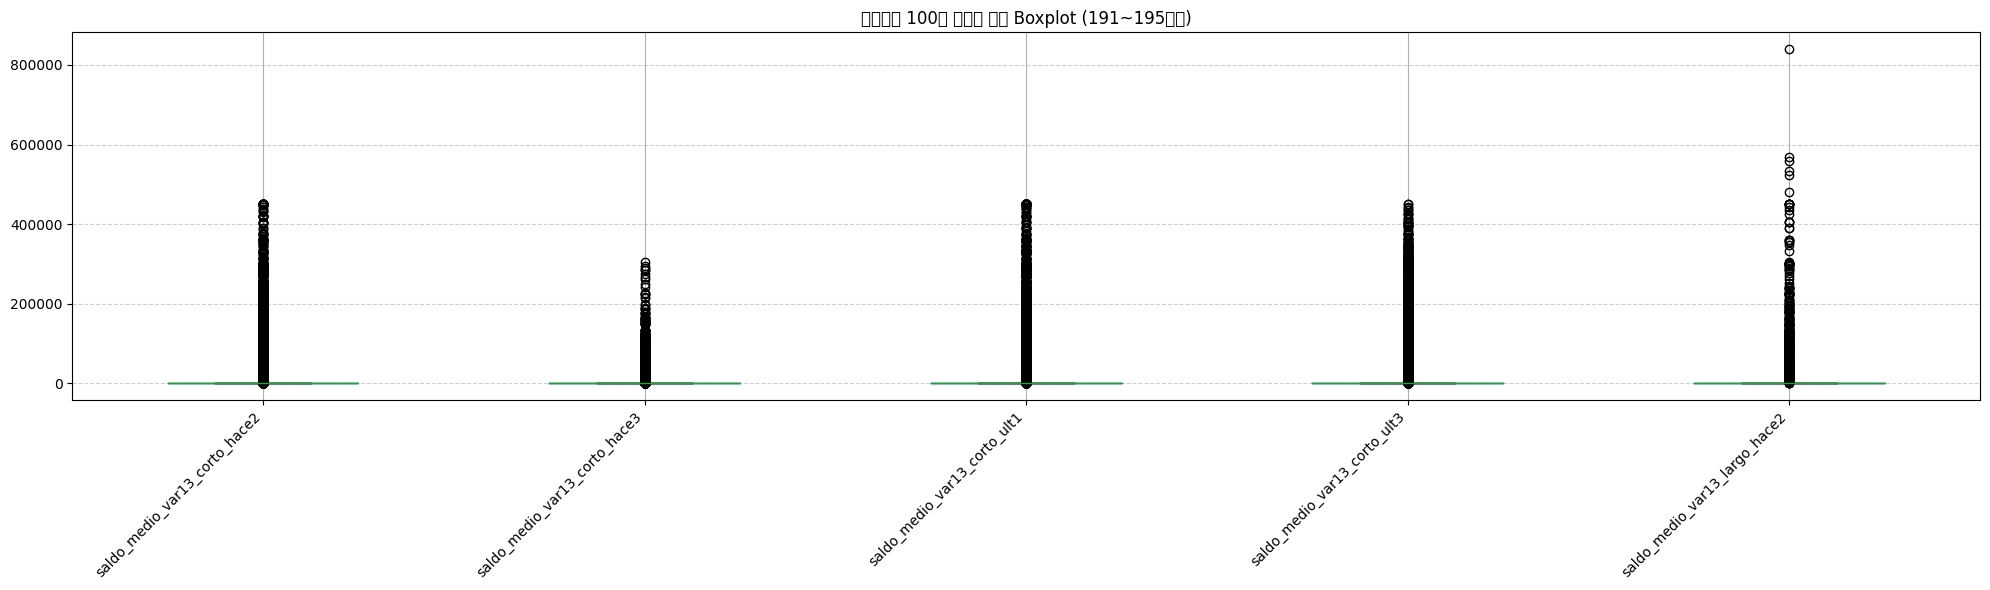

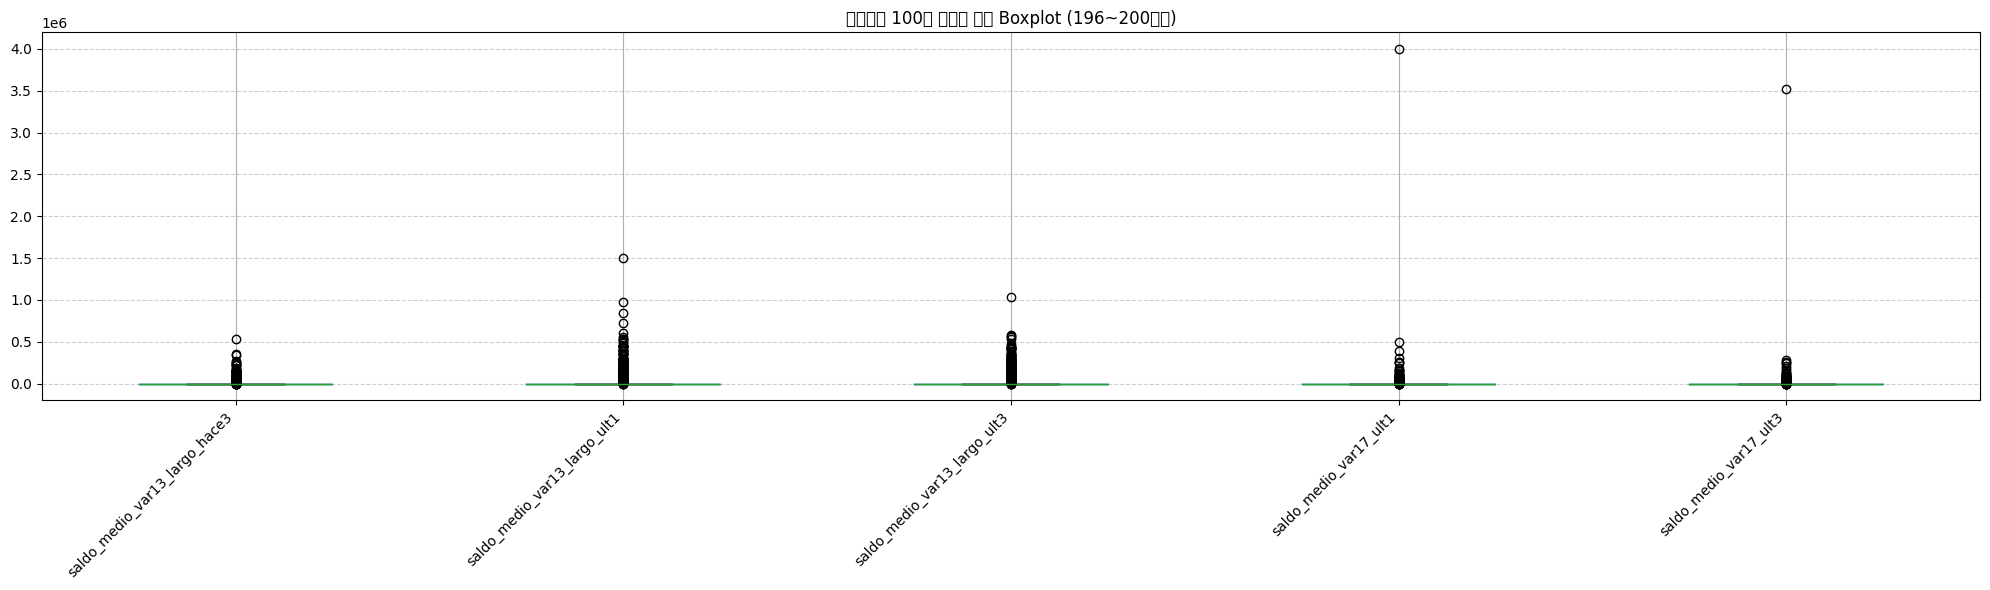

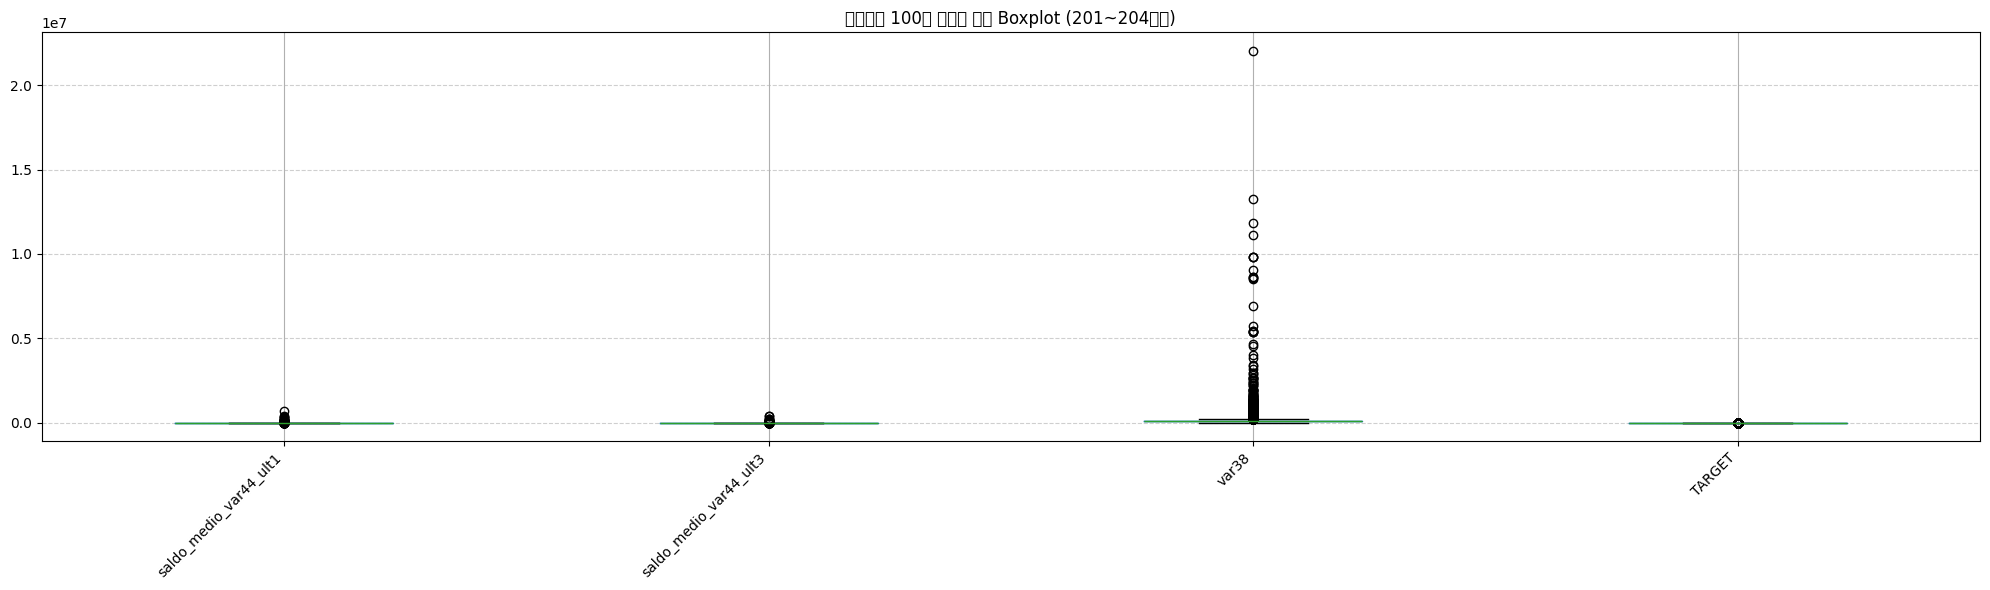

In [59]:
# 6. 10개씩 나눠서 Boxplot 시각화
chunk_size = 5
for i in range(0, len(selected_cols), chunk_size):
    chunk = selected_cols[i:i + chunk_size]

    plt.figure(figsize=(20, 6))
    df[chunk].boxplot()
    plt.title(f"이상치가 {ncnt}개 이상인 컬럼 Boxplot ({i+1}~{i+len(chunk)}번째)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


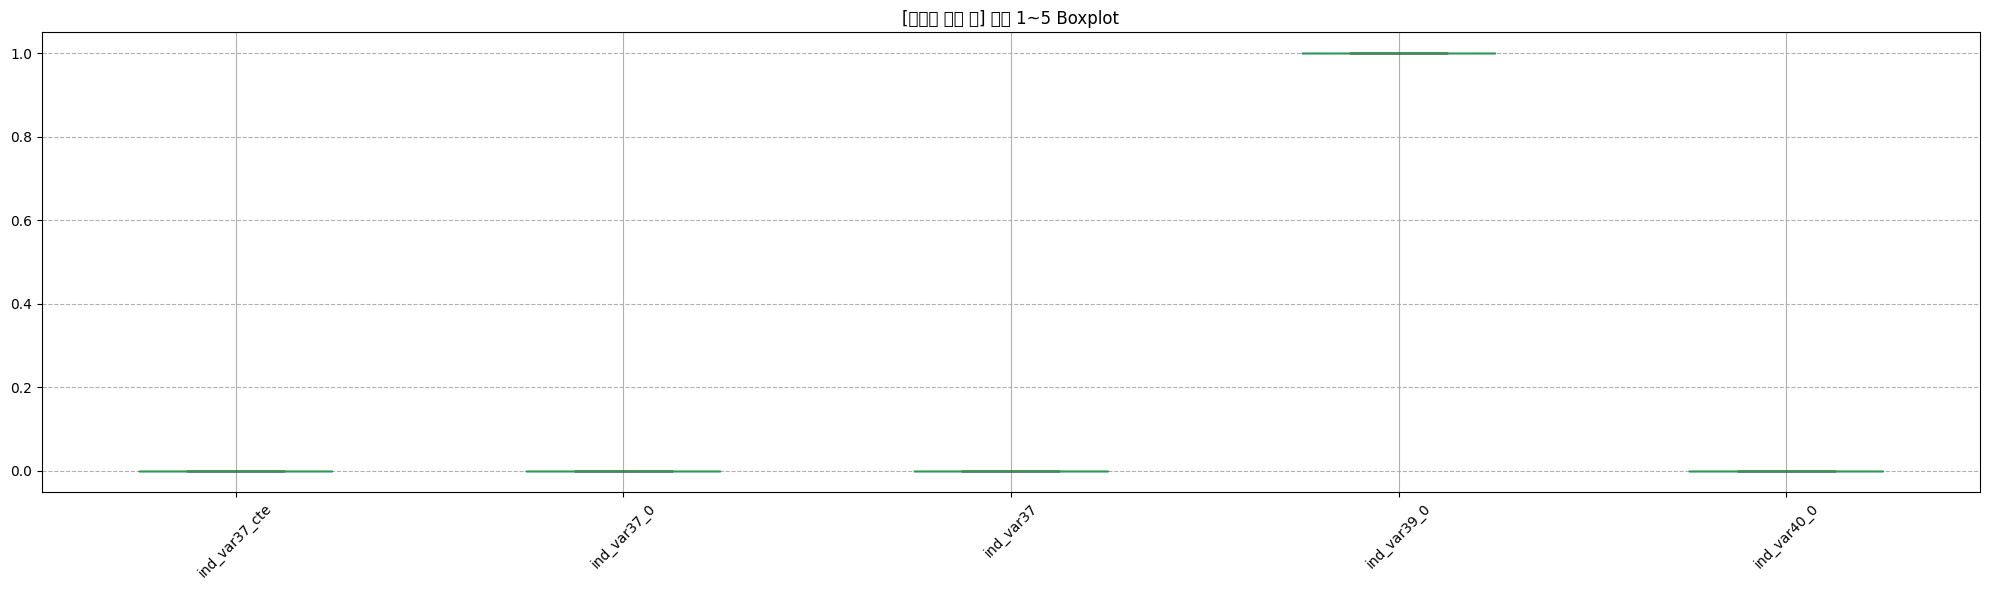

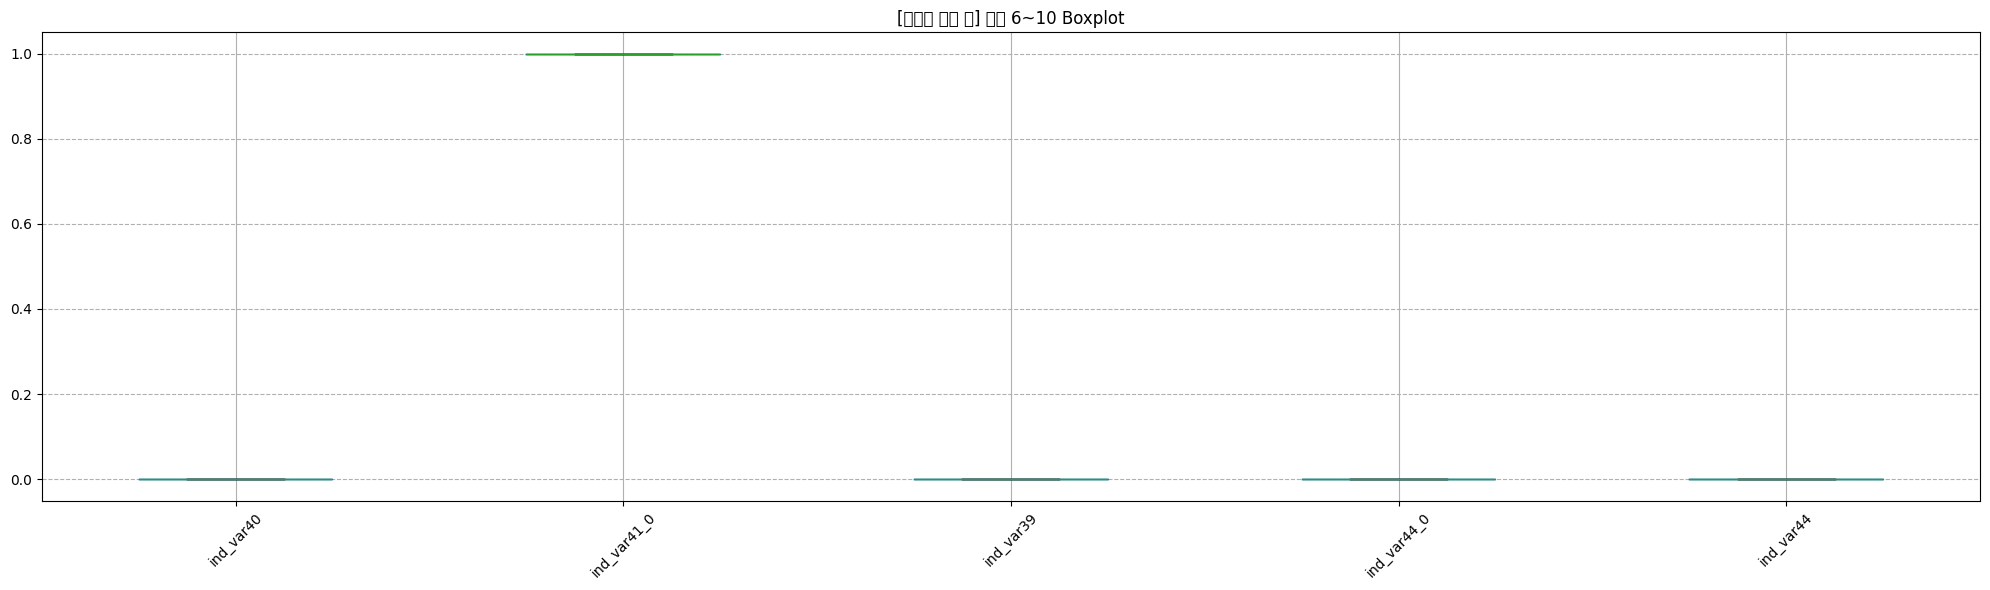

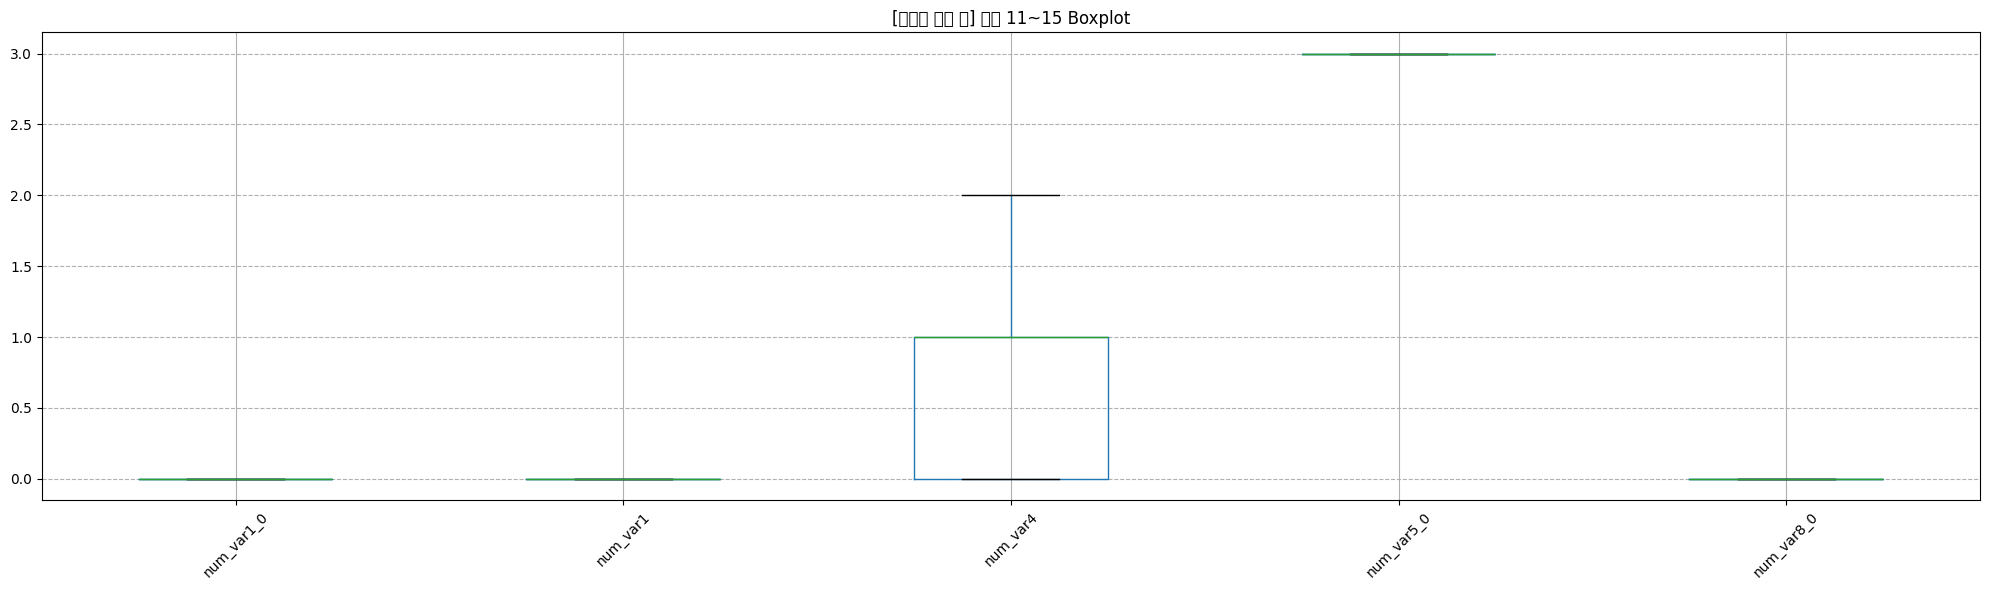

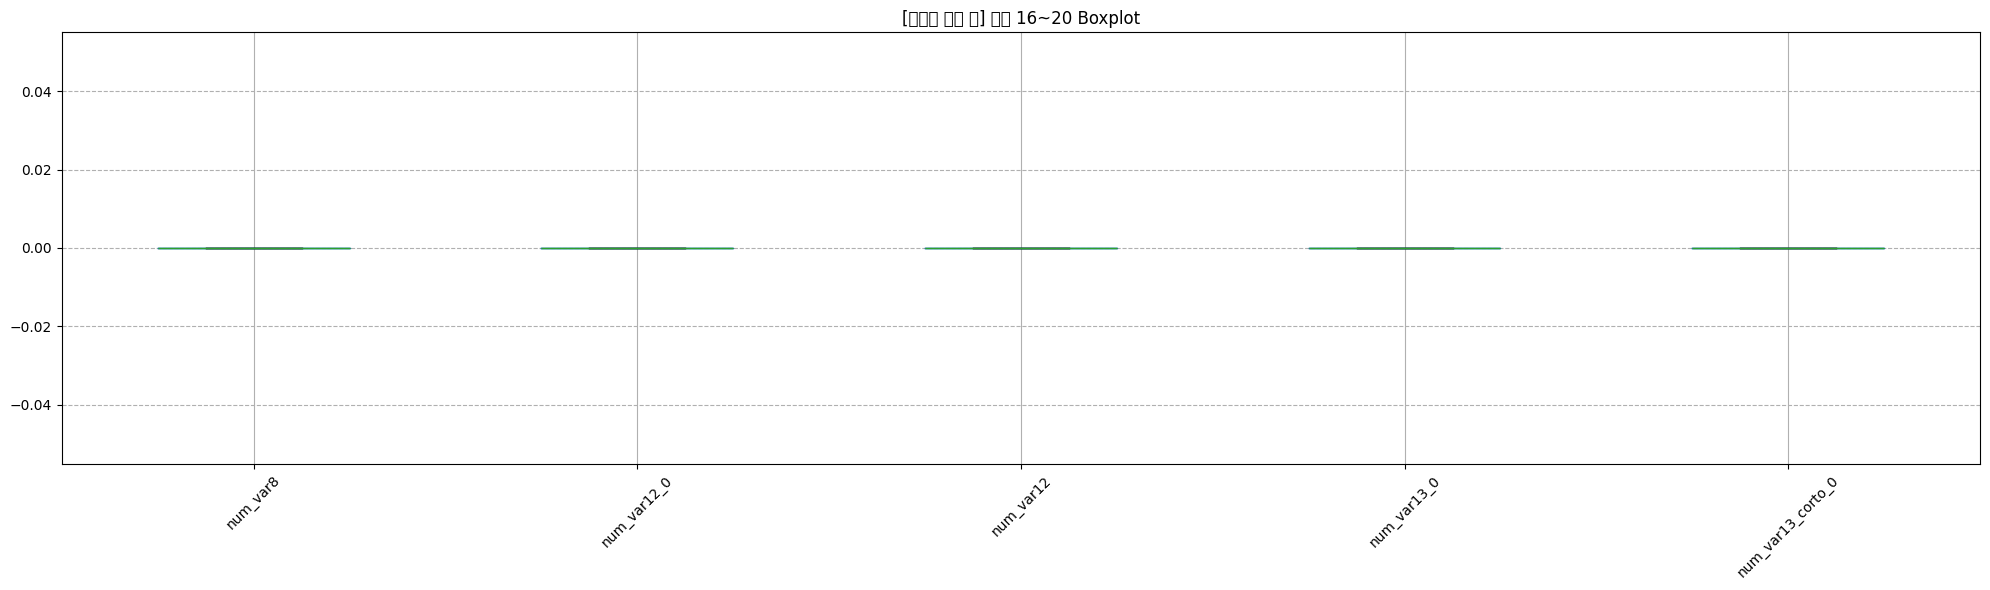

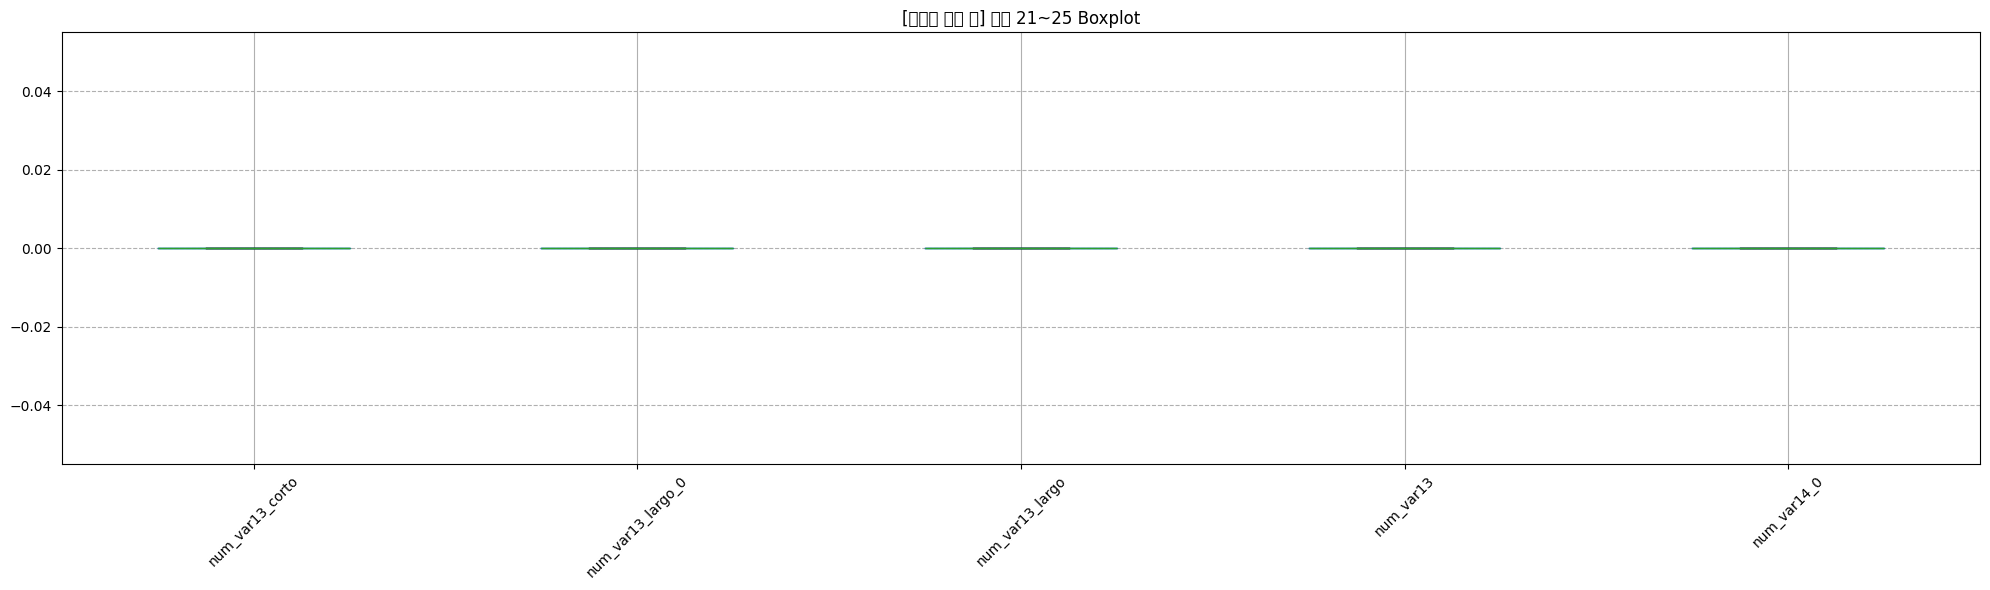

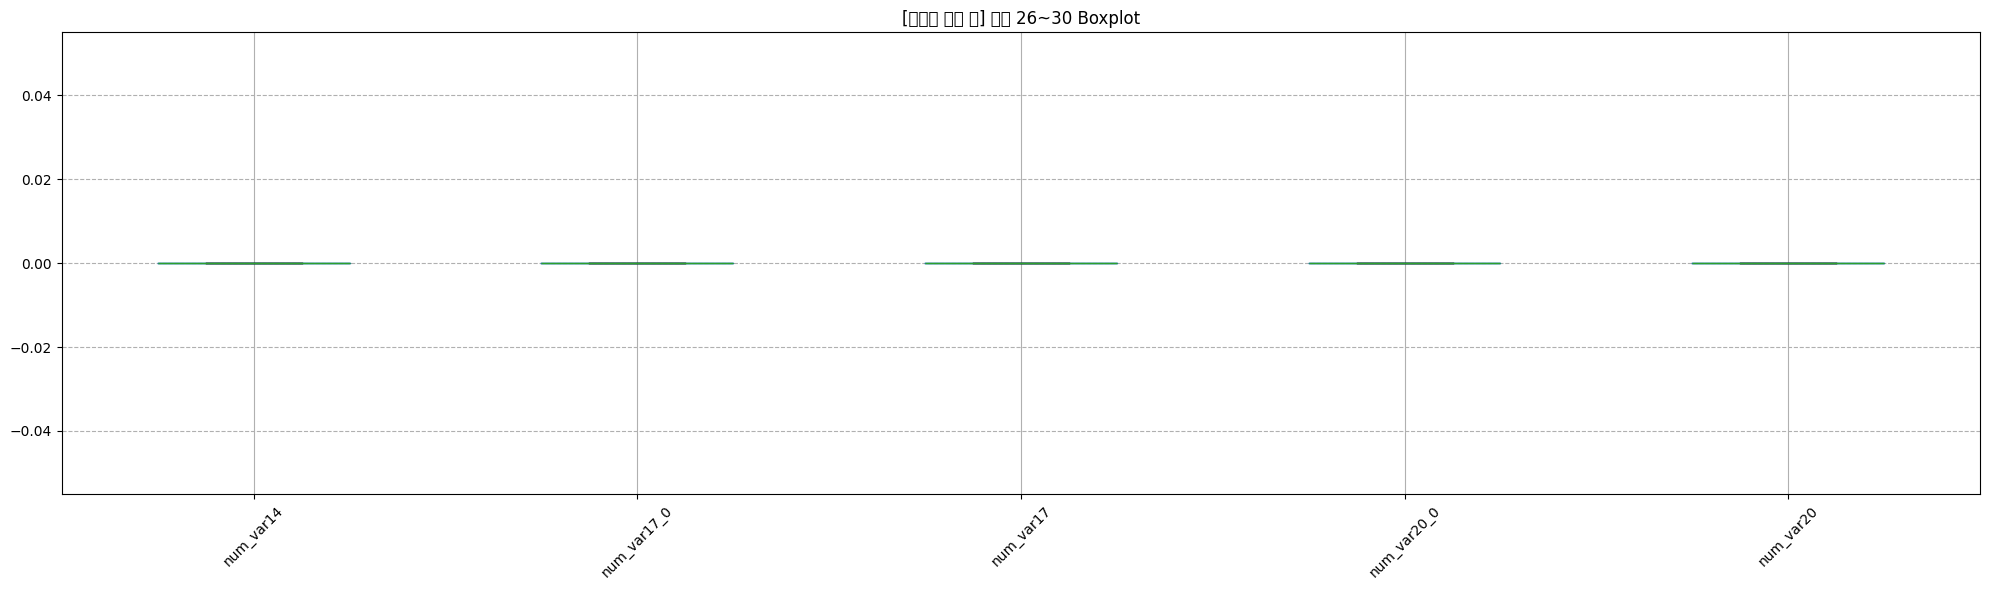

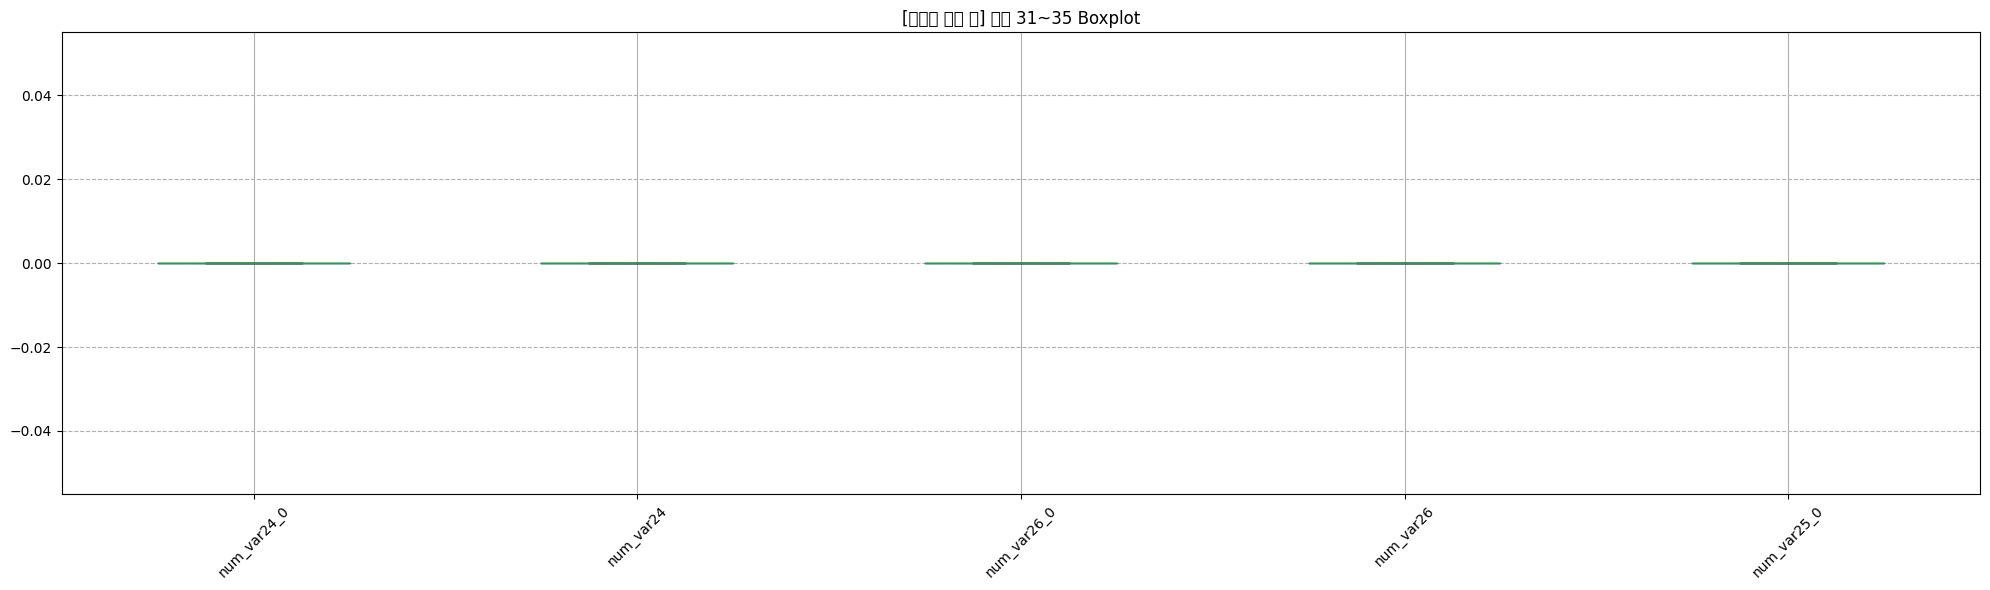

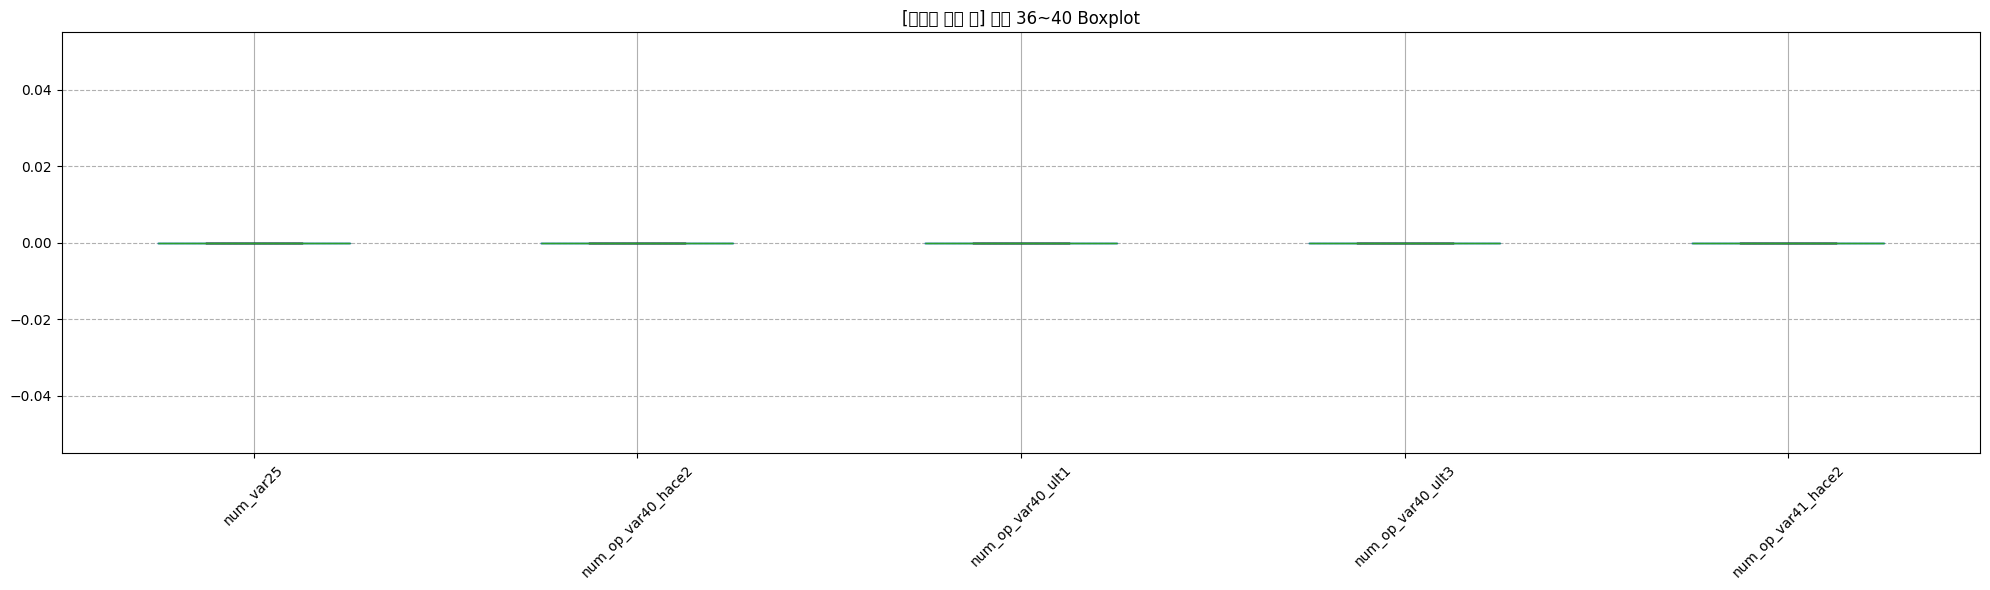

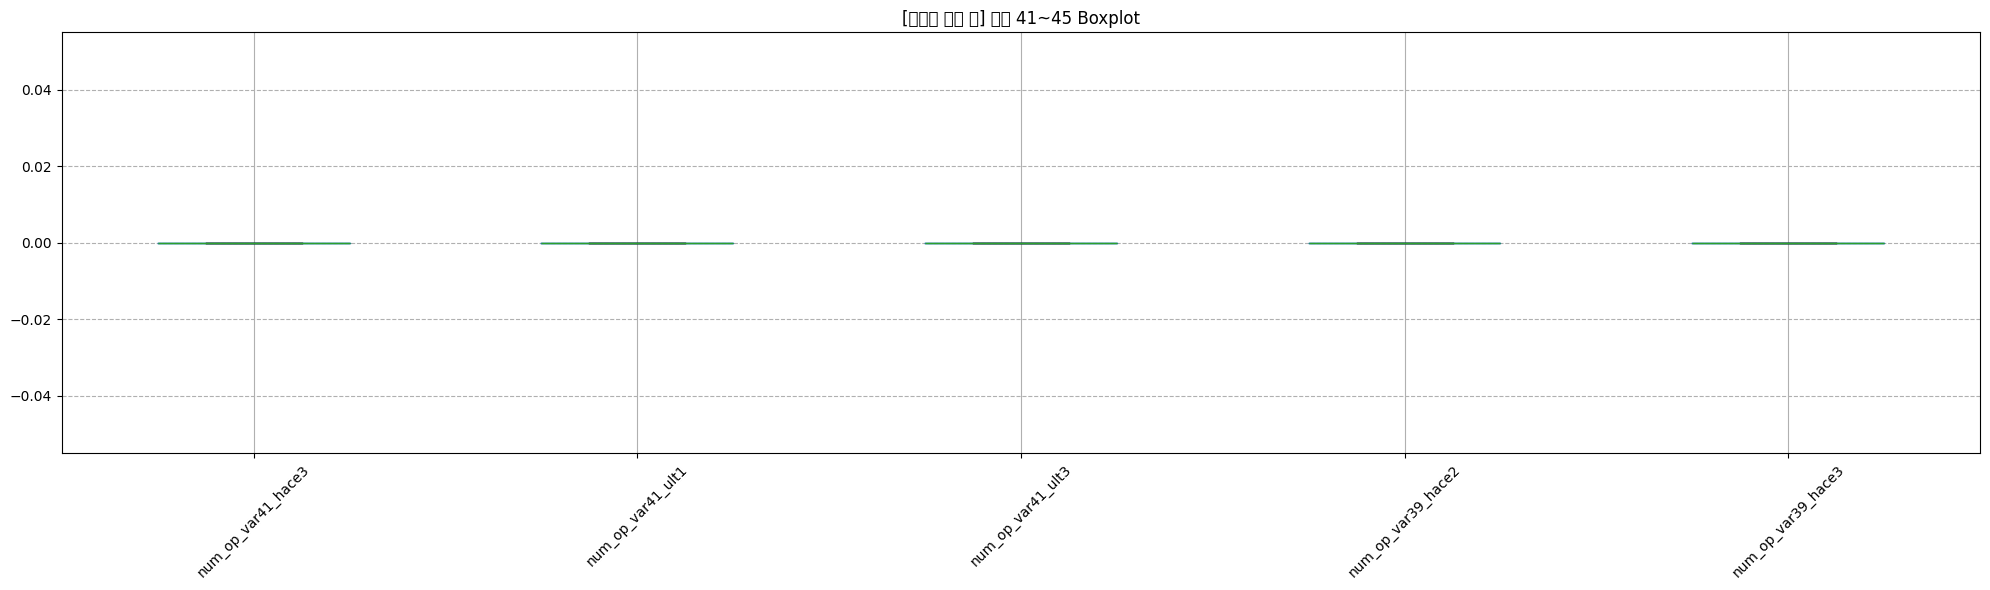

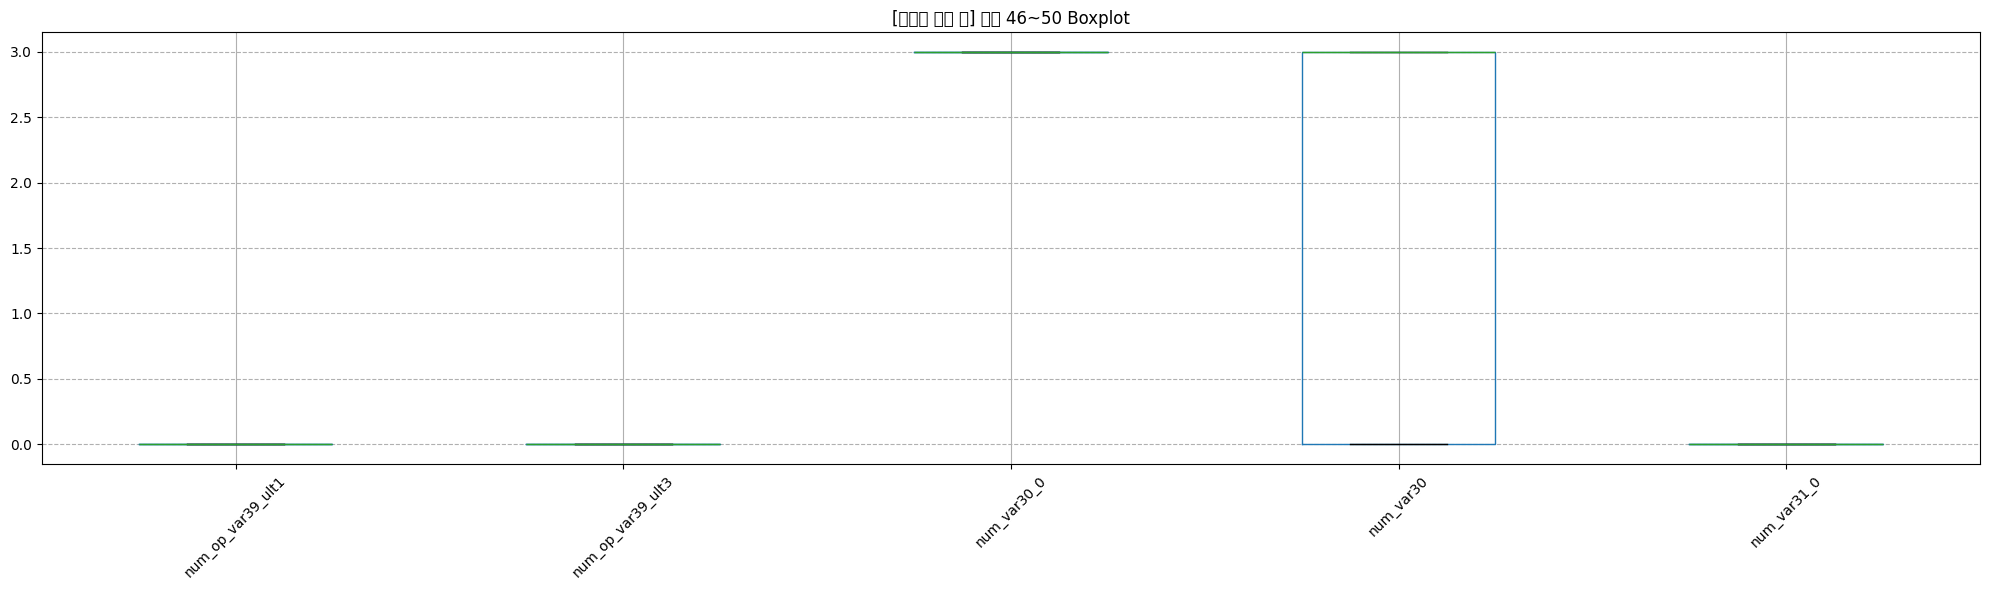

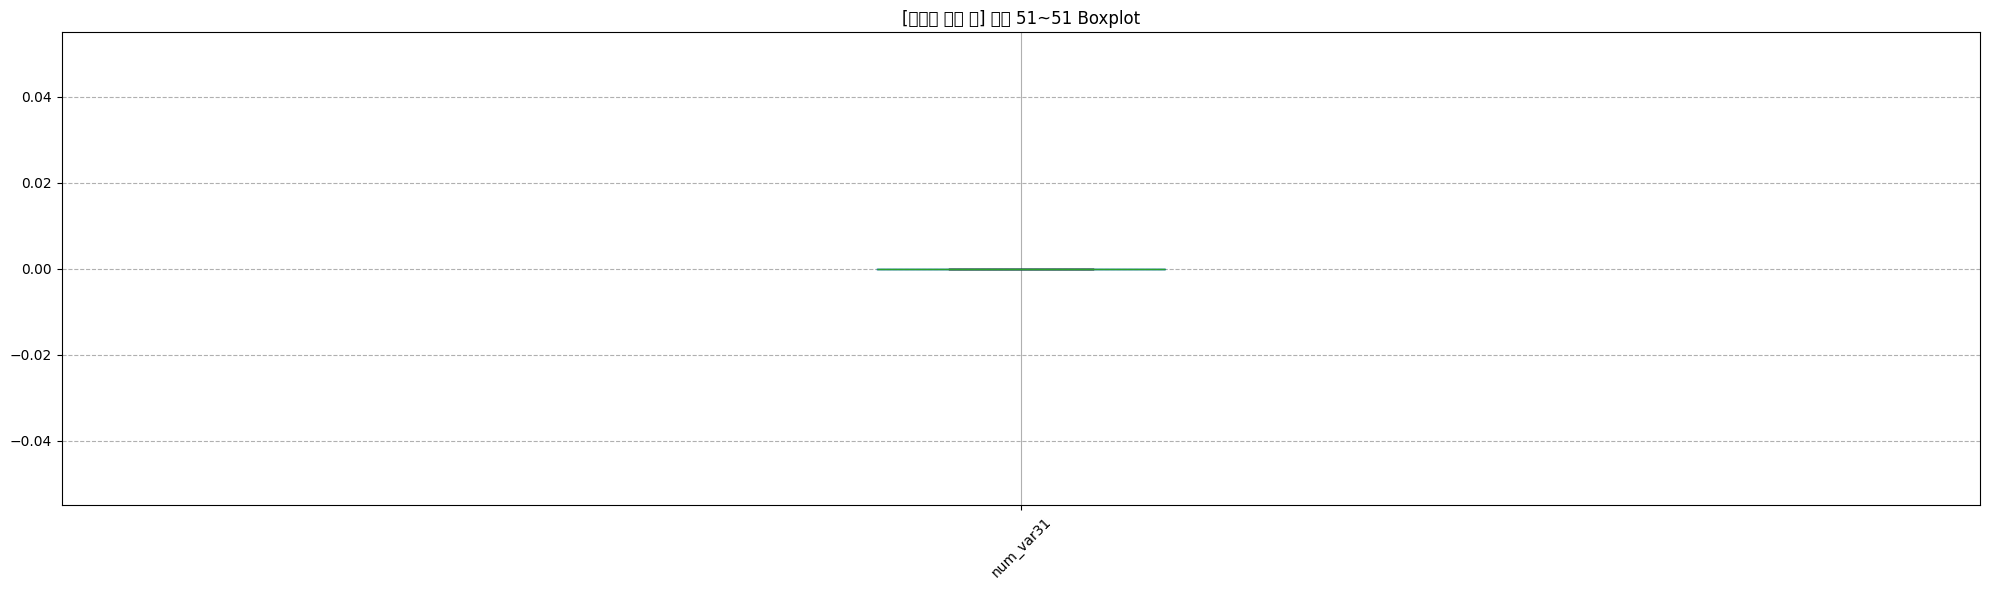

In [49]:
# 6. 10개씩 나눠서 Boxplot 시각화
# chunk_size = 5
# for i in range(0, len(selected_cols), chunk_size):
#     chunk = selected_cols[i:i + chunk_size]

#     plt.figure(figsize=(20, 6))
#     df[chunk].boxplot()
#     plt.title(f"이상치가 {ncnt}개 이상인 컬럼 Boxplot ({i+1}~{i+len(chunk)}번째)")
#     plt.xticks(rotation=45, ha="right")
#     plt.grid(True, axis="y", linestyle="--", alpha=0.6)
#     plt.tight_layout()
#     plt.show()

# --------------------------------------
# 8. 5개씩 나눠서 재시각화
# --------------------------------------
chunk_size = 5
for i in range(0, len(selected_cols), chunk_size):
    chunk = selected_cols[i:i + chunk_size]

    plt.figure(figsize=(20, 6))
    df_clean[chunk].boxplot()
    plt.title(f"[이상치 제거 후] 컬럼 {i+1}~{i+len(chunk)} Boxplot")
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()


In [52]:
df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000
